## Final Project

This notebook contains the full code for our final project, which focuses on **binary image classification: Asian vs. Non-Asian**.

We explore a range of models and techniques across the following sections:

1. **Exploratory & Unsupervised Analysis** — Data loading, normalization, PCA visualization, and K-Means clustering to understand the structure of the data.

2. **Logistic Regression** — We experiment with multiple feature representations:
   - Raw flattened pixels (no PCA)
   - PCA-reduced features (top 50 components)
   - Polynomial (degree-2) feature transformation on PCA components
   
   For each, we compare **unregularized** and **L2** regularization to study the bias-variance tradeoff.

3. **Neural Networks (Fully Connected)** — We test several MLP architectures of increasing depth and width, again sweeping over L2 regularization and dropping out strengths. We also experiment with PCA-compressed inputs as an alternative to raw pixels.

4. **Convolutional Neural Networks (CNN)** — We build and compare four CNN architectures of increasing complexity, from a simple single-conv-layer model to a deeper network with Batch Normalization and multiple convolutional blocks.

5. **Conclusion** — We compare all models by their validation/test performance and summarize key findings.

> **Dataset:** Face images resized to 64×64 RGB (12,288 features per image), split into 70% train / 15% validation / 15% test with stratification. https://data.mendeley.com/datasets/6wcczyfdrb/1

## 1. Exploratory & Unsupervised Analysis

Before training any model, we explore the dataset to understand its structure and distribution.  
This section covers:
- **Data loading & preprocessing** — loading 64×64 RGB face images, normalizing pixel values, and splitting into train/val/test sets
- **Mean face visualization** — comparing the average face of each class to spot visual differences
- **PCA** — reducing dimensionality and visualizing how well the two classes separate in principal component space
- **K-Means clustering** — testing whether the data has a natural grouping that aligns with the Asian / Non-Asian labels

### 1.1 Mount Google Drive & Load Data

We load face images from Google Drive. Images are pre-cropped and resized to **64×64 pixels** in RGB format.  
Each image is read with PIL, converted to a NumPy array, and assigned a binary label:  
- `1` → Asian  
- `0` → Non-Asian

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
import numpy as np
from PIL import Image
from sklearn.model_selection import train_test_split

asian_path = "/content/drive/MyDrive/NYU/CS-UY 4564 Machine Learning/Project/Dataset/Asian/64 x 64 Size Cropped Images"
non_asian_path = "/content/drive/MyDrive/NYU/CS-UY 4564 Machine Learning/Project/Dataset/Non Asian/64 x 64 Size Cropped Images"

def load_images_from_folder(folder_path, label):
    images = []
    labels = []
    for filename in os.listdir(folder_path):
        if filename.lower().endswith('.jpg'):
            img_path = os.path.join(folder_path, filename)
            try:
                img = Image.open(img_path).convert('RGB')
                img_array = np.array(img)
                images.append(img_array)
                labels.append(label)
            except Exception as e:
                print(f"Skipping corrupted file {filename}: {e}")
    return images, labels

# Load images (Asian=1, Non-Asian=0)
asian_images, asian_labels = load_images_from_folder(asian_path, label=1)
non_asian_images, non_asian_labels = load_images_from_folder(non_asian_path, label=0)

# Merge
X = np.array(asian_images + non_asian_images)
y = np.array(asian_labels + non_asian_labels)

print(f"Asian images:     {len(asian_images)}")
print(f"Non-Asian images: {len(non_asian_images)}")
print(f"X shape: {X.shape}, y shape: {y.shape}")
print(f"Pixel value range: [{X.min()}, {X.max()}]")

Asian images:     1382
Non-Asian images: 1725
X shape: (3107, 64, 64, 3), y shape: (3107,)
Pixel value range: [0, 255]


### 1.2 Mean Face & Pixel Difference

We compute the **per-pixel average** across all images in each class.  
The difference heatmap (Asian − Non-Asian) highlights regions where the two groups differ most in brightness — warmer colors indicate areas where Asian faces tend to be; brighter, cooler colors indicate the opposite.

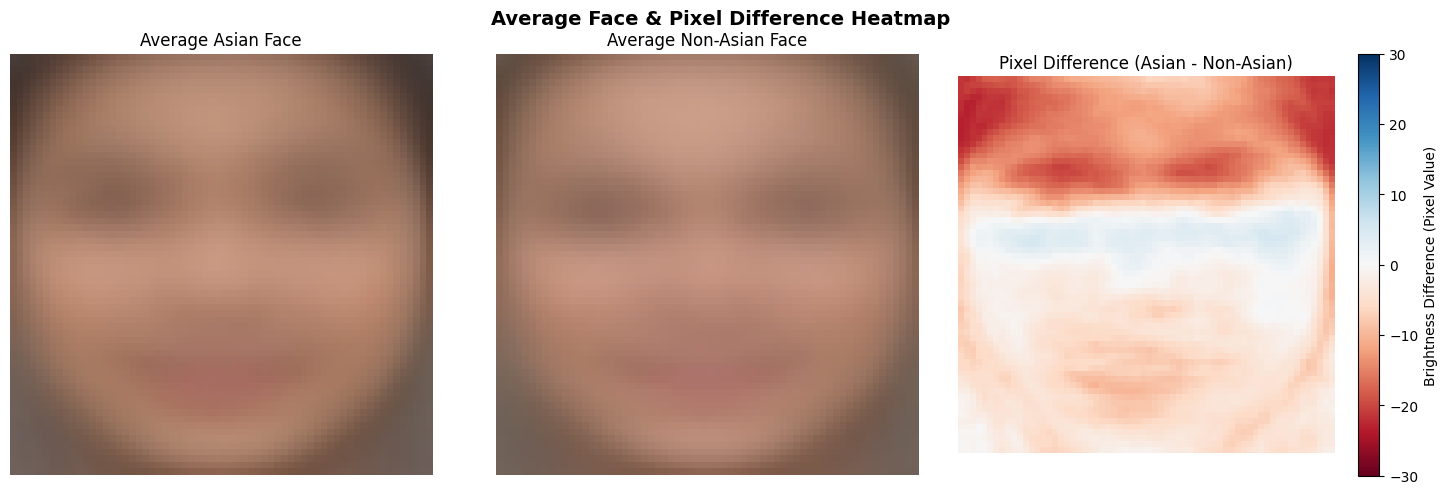

In [ ]:
import matplotlib.pyplot as plt

asian_X = X[y == 1]
non_asian_X = X[y == 0]

asian_mean = asian_X.mean(axis=0)
non_asian_mean = non_asian_X.mean(axis=0)

difference = asian_mean - non_asian_mean
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(asian_mean.astype(np.uint8))
axes[0].set_title('Average Asian Face')
axes[0].axis('off')
axes[1].imshow(non_asian_mean.astype(np.uint8))
axes[1].set_title('Average Non-Asian Face')
axes[1].axis('off')
diff_plot = axes[2].imshow(difference.mean(axis=2), cmap='RdBu', vmin=-30, vmax=30)
axes[2].set_title('Pixel Difference (Asian - Non-Asian)')
axes[2].axis('off')
plt.colorbar(diff_plot, ax=axes[2], label='Brightness Difference (Pixel Value)')
plt.suptitle('Average Face & Pixel Difference Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### 1.3 Normalization & Train / Val / Test Split

Pixel values are scaled from `[0, 255]` to `[0.0, 1.0]` by dividing by 255.  
The dataset is then split with **stratification** to preserve class balance:
- **70%** training
- **15%** validation
- **15%** test

In [ ]:
X_normalized = X / 255.0
X_train, X_temp, y_train, y_temp = train_test_split(X_normalized, y, test_size=0.30, random_state=42, stratify=y)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp)

### 1.4 PCA — Dimensionality Reduction

Raw 64×64 RGB images contain **12,288 features** per sample, which is very high-dimensional.  
We flatten each image and fit **PCA on the training set only** (then apply the same transform to val/test) to avoid data leakage.  
PCA is run with all components first so we can inspect the explained variance curve before choosing how many to keep.

In [ ]:
from sklearn.decomposition import PCA

n_train = X_train.shape[0]
n_val = X_val.shape[0]
n_test = X_test.shape[0]

X_train_flat = X_train.reshape(n_train, -1)
X_val_flat = X_val.reshape(n_val, -1)
X_test_flat = X_test.reshape(n_test, -1)

pca = PCA()
X_train_pca = pca.fit_transform(X_train_flat)

### 1.5 Scree Plot — Choosing the Number of Components

The cumulative explained variance plot (scree plot) shows how much total variance is captured as we add more PCA components.  
We use the **95% variance threshold** as a practical cutoff — the vertical dashed line marks the minimum number of components needed to retain 95% of the information in the training data.

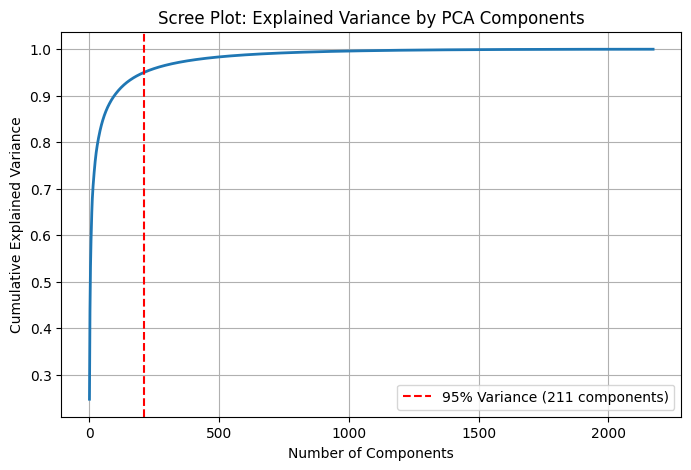

To retain 95% of the variance, we need 211 components.


In [ ]:
cum_explained_variance = np.cumsum(pca.explained_variance_ratio_)

plt.figure(figsize=(8, 5))
plt.plot(cum_explained_variance, linewidth=2)
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('Scree Plot: Explained Variance by PCA Components')
plt.grid(True)

n_95 = np.argmax(cum_explained_variance >= 0.95) + 1
plt.axvline(x=n_95, color='r', linestyle='--', label=f'95% Variance ({n_95} components)')
plt.legend()
plt.show()

print(f"To retain 95% of the variance, we need {n_95} components.")

### 1.6 2D PCA Scatter Plot

We project the training data onto its first two principal components and color each point by its true label.  
If the two classes form visually distinct clusters in this 2D view, it suggests that PCA features carry useful discriminative signal for classification.

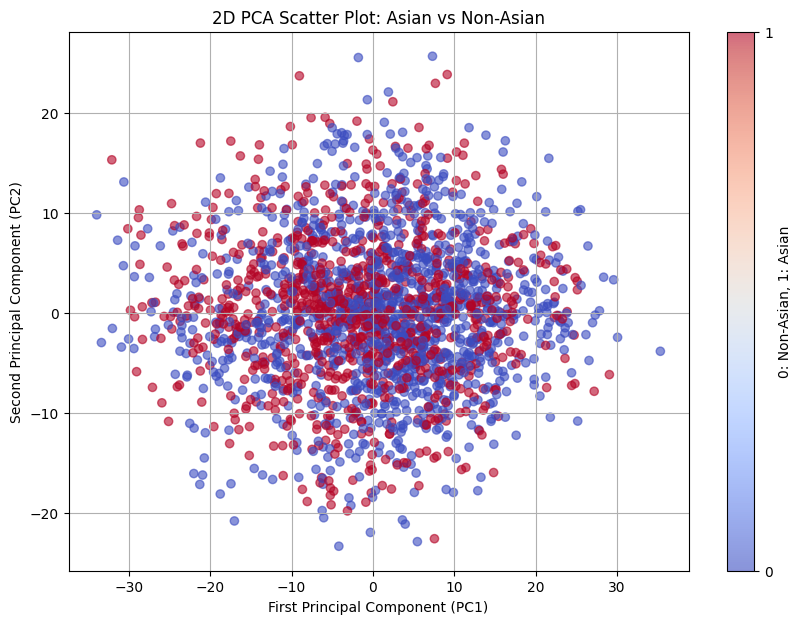

In [ ]:
plt.figure(figsize=(10, 7))
scatter = plt.scatter(X_train_pca[:, 0], X_train_pca[:, 1], c=y_train, cmap='coolwarm', alpha=0.6)
plt.colorbar(scatter, ticks=[0, 1], label='0: Non-Asian, 1: Asian')
plt.xlabel('First Principal Component (PC1)')
plt.ylabel('Second Principal Component (PC2)')
plt.title('2D PCA Scatter Plot: Asian vs Non-Asian')
plt.grid(True)
plt.show()

### 1.7 Distribution of the First 5 Principal Components

For each of the first five PCs, we plot the **density histogram** separately for Asian and Non-Asian samples.  
Overlapping distributions indicate that a single component alone is insufficient for separation; the degree of separation across components gives a rough sense of which PCs are most informative.

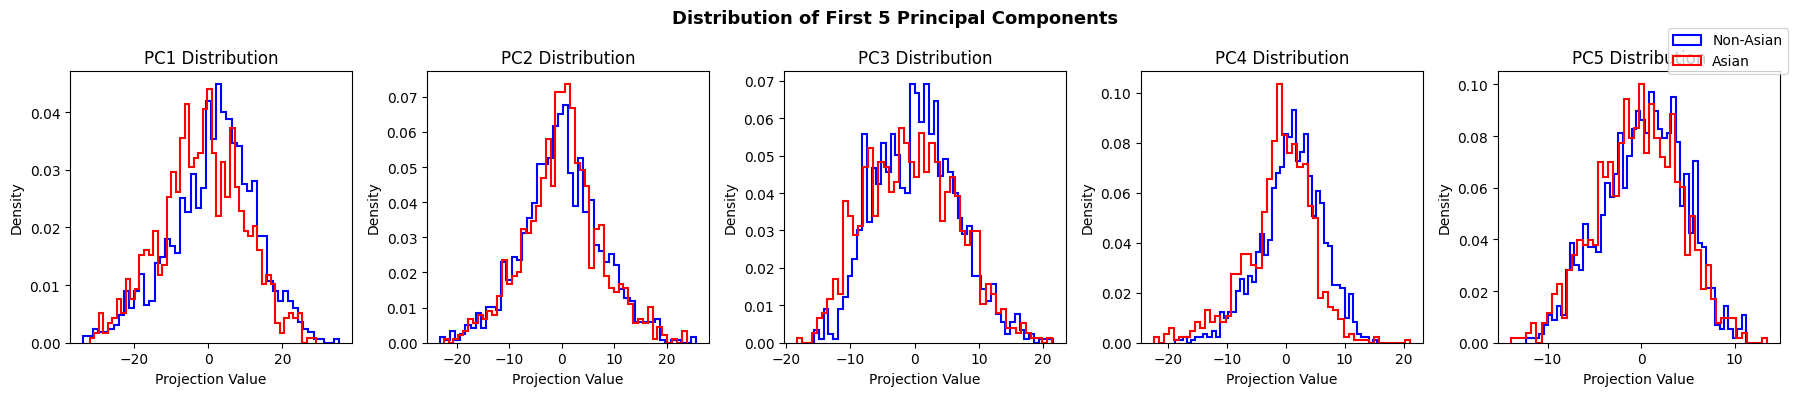

In [ ]:
fig, axes = plt.subplots(1, 5, figsize=(18, 4))
for i, ax in enumerate(axes):
    ax.hist(X_train_pca[y_train == 0, i], bins=50, histtype='step', linewidth=1.5, color='blue', density=True, label='Non-Asian')
    ax.hist(X_train_pca[y_train == 1, i], bins=50, histtype='step', linewidth=1.5, color='red', density=True, label='Asian')
    ax.set_title(f'PC{i+1} Distribution')
    ax.set_xlabel('Projection Value')
    ax.set_ylabel('Density')
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper right', bbox_to_anchor=(1.0, 0.95))
plt.suptitle('Distribution of First 5 Principal Components', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()
plt.show()

### 1.8 K-Means Clustering

As an unsupervised baseline, we apply **K-Means (k=2)** on the PCA-reduced training data (using the top components that explain 95% of variance) and compare the resulting cluster assignments to the true labels using the **Adjusted Rand Index (ARI)**.  
- ARI = 1.0 → perfect match with true labels  
- ARI ≈ 0.0 → clustering no better than random  

This tells us whether the dataset has a natural geometry that roughly aligns with the Asian / Non-Asian distinction, without using any label information during clustering.

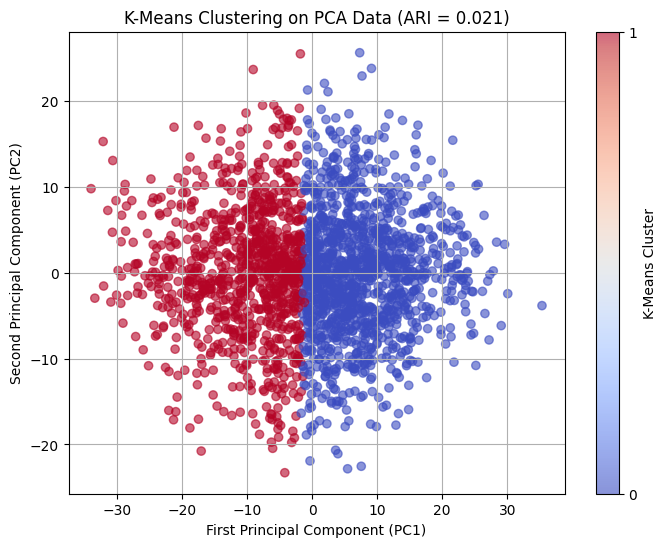

Adjusted Rand Index (ARI): 0.0209


In [ ]:
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score

kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(X_train_pca[:, :n_95])

ari = adjusted_rand_score(y_train, cluster_labels)

plt.figure(figsize=(8, 6))
scatter = plt.scatter(X_train_pca[:, 0], X_train_pca[:, 1], c=cluster_labels, cmap='coolwarm', alpha=0.6)
plt.colorbar(scatter, ticks=[0, 1], label='K-Means Cluster')
plt.xlabel('First Principal Component (PC1)')
plt.ylabel('Second Principal Component (PC2)')
plt.title(f'K-Means Clustering on PCA Data (ARI = {ari:.3f})')
plt.grid(True)
plt.show()

print(f"Adjusted Rand Index (ARI): {ari:.4f}")

## 2. Logistic Regression

## 2. Logistic Regression

In this section, we apply Logistic Regression under three different feature representations,
and for each representation we compare **no regularization** vs. **L2 regularization** across a range of λ values.

The three feature setups are:
| Setup | Features | Dimensionality |
|---|---|---|
| Raw Pixels | Flattened 64×64 RGB image | 12,288 |
| PCA (top-*k* components) | Components retaining 95% variance | *k* ≈ n_95 |
| PCA + Polynomial (degree 2) | Quadratic features on top-50 / top-25 PCs | ~1,326 / ~351 |

For regularization, we sweep λ ∈ {0.1, 1, 10, 100, 1000, 10000}.  
Note: sklearn uses `C = 1/λ`, so larger λ means stronger regularization.

Metrics reported: **Train Accuracy, Val Accuracy, Precision, Recall, Specificity**.

### 2.1 Raw Pixels — No Regularization

As a baseline, we train Logistic Regression directly on the **flattened raw pixel features** (12,288-dimensional)
without any regularization (`penalty=None`).

With 12,288 features and a relatively small dataset, we expect this model to **overfit** significantly —
high train accuracy but lower val accuracy.

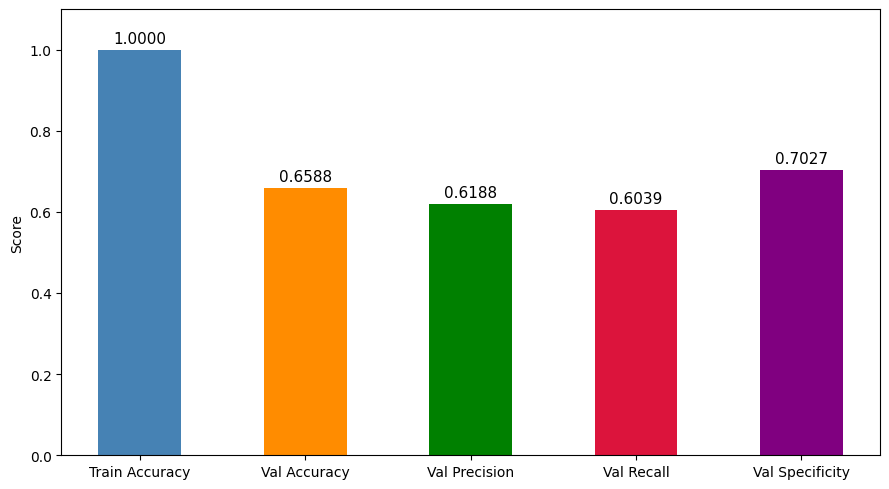

In [ ]:
# Logistic with no PCA
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix

X_train_lr = X_train_flat
X_val_lr = X_val_flat
X_test_lr = X_test_flat

lr_no_reg = LogisticRegression(penalty=None, max_iter=1000, random_state=42)
lr_no_reg.fit(X_train_lr, y_train)

train_acc = accuracy_score(y_train, lr_no_reg.predict(X_train_lr))
val_preds = lr_no_reg.predict(X_val_lr)
val_acc = accuracy_score(y_val, val_preds)
val_precision = precision_score(y_val, val_preds)
val_recall = recall_score(y_val, val_preds)
tn, fp, fn, tp = confusion_matrix(y_val, val_preds).ravel()
val_specificity = tn / (tn + fp)

metrics = [train_acc, val_acc, val_precision, val_recall, val_specificity]
labels = ['Train Accuracy', 'Val Accuracy', 'Val Precision', 'Val Recall', 'Val Specificity']
colors = ['steelblue', 'darkorange', 'green', 'crimson', 'purple']

plt.figure(figsize=(9, 5))
bars = plt.bar(labels, metrics, color=colors, width=0.5)
for bar, val in zip(bars, metrics):
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01, f'{val:.4f}', ha='center', va='bottom', fontsize=11)
plt.ylim(0, 1.1)
plt.ylabel('Score')
plt.tight_layout()
plt.show()

### 2.2 Raw Pixels — L2 Regularization Sweep

We now apply **L2 (Ridge) regularization** on the same raw pixel features,
sweeping λ from 0.1 to 10,000.

L2 regularization penalizes large weights, shrinking them toward zero and reducing overfitting.
The dashed lines show the unregularized baseline from 2.1 for comparison.

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix

unregularized_metrics = {
    'train_acc': train_acc,
    'val_acc': val_acc,
    'val_precision': val_precision,
    'val_recall': val_recall,
    'val_specificity': val_specificity
}

lambda_values = [0.1, 1, 10, 100, 1000, 10000]
l2_metrics = []

for lam in lambda_values:
    print(lam)
    model = LogisticRegression(penalty='l2', C=1/lam, max_iter=1000, random_state=42)
    model.fit(X_train_lr, y_train)

    train_preds = model.predict(X_train_lr)
    val_preds = model.predict(X_val_lr)

    t_acc = accuracy_score(y_train, train_preds)
    v_acc = accuracy_score(y_val, val_preds)
    v_prec = precision_score(y_val, val_preds)
    v_rec = recall_score(y_val, val_preds)
    tn, fp, fn, tp = confusion_matrix(y_val, val_preds).ravel()
    v_spec = tn / (tn + fp)

    l2_metrics.append({
        'lambda': lam,
        'train_acc': t_acc,
        'val_acc': v_acc,
        'val_precision': v_prec,
        'val_recall': v_rec,
        'val_specificity': v_spec
    })

for m in l2_metrics:
    print(f"λ={m['lambda']:>6} | Train Acc: {m['train_acc']:.4f} | Val Acc: {m['val_acc']:.4f} | "
          f"Precision: {m['val_precision']:.4f} | Recall: {m['val_recall']:.4f} | Specificity: {m['val_specificity']:.4f}")

0.1
1
10
100
1000
10000
λ=   0.1 | Train Acc: 1.0000 | Val Acc: 0.6888 | Precision: 0.6582 | Recall: 0.6232 | Specificity: 0.7413
λ=     1 | Train Acc: 0.9867 | Val Acc: 0.6974 | Precision: 0.6701 | Recall: 0.6280 | Specificity: 0.7529
λ=    10 | Train Acc: 0.8827 | Val Acc: 0.7103 | Precision: 0.6818 | Recall: 0.6522 | Specificity: 0.7568
λ=   100 | Train Acc: 0.7847 | Val Acc: 0.7318 | Precision: 0.7204 | Recall: 0.6473 | Specificity: 0.7992
λ=  1000 | Train Acc: 0.7226 | Val Acc: 0.7124 | Precision: 0.7212 | Recall: 0.5749 | Specificity: 0.8224
λ= 10000 | Train Acc: 0.6628 | Val Acc: 0.6545 | Precision: 0.6949 | Recall: 0.3961 | Specificity: 0.8610


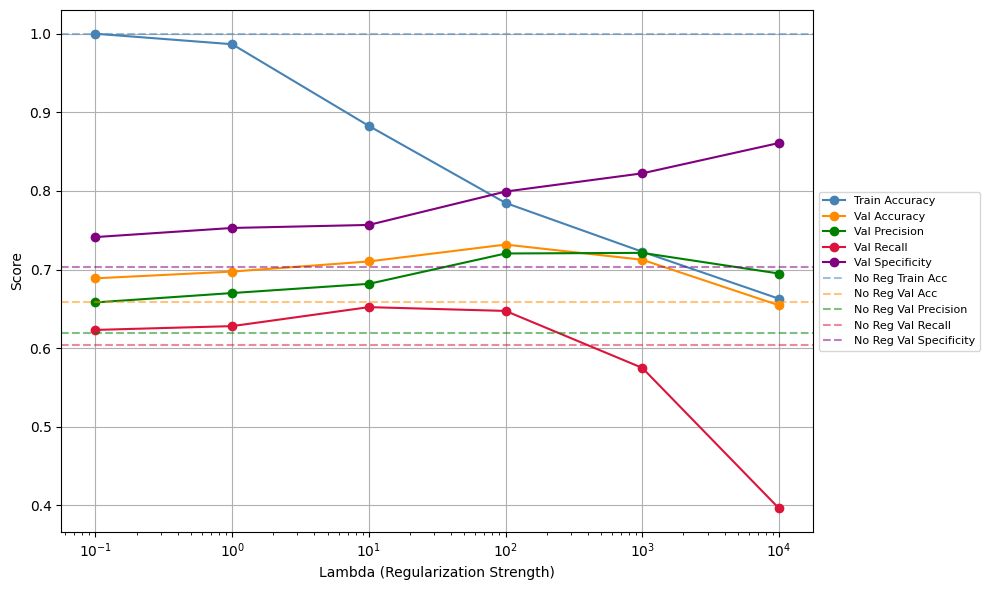

In [ ]:
import matplotlib.pyplot as plt

train_accs = [m['train_acc'] for m in l2_metrics]
val_accs = [m['val_acc'] for m in l2_metrics]
val_precs = [m['val_precision'] for m in l2_metrics]
val_recs = [m['val_recall'] for m in l2_metrics]
val_specs = [m['val_specificity'] for m in l2_metrics]

plt.figure(figsize=(10, 6))
plt.plot(lambda_values, train_accs, marker='o', color='steelblue', label='Train Accuracy')
plt.plot(lambda_values, val_accs, marker='o', color='darkorange', label='Val Accuracy')
plt.plot(lambda_values, val_precs, marker='o', color='green', label='Val Precision')
plt.plot(lambda_values, val_recs, marker='o', color='crimson', label='Val Recall')
plt.plot(lambda_values, val_specs, marker='o', color='purple', label='Val Specificity')

plt.axhline(y=unregularized_metrics['train_acc'], color='steelblue', linestyle='--', alpha=0.5, label='No Reg Train Acc')
plt.axhline(y=unregularized_metrics['val_acc'], color='darkorange', linestyle='--', alpha=0.5, label='No Reg Val Acc')
plt.axhline(y=unregularized_metrics['val_precision'], color='green', linestyle='--', alpha=0.5, label='No Reg Val Precision')
plt.axhline(y=unregularized_metrics['val_recall'], color='crimson', linestyle='--', alpha=0.5, label='No Reg Val Recall')
plt.axhline(y=unregularized_metrics['val_specificity'], color='purple', linestyle='--', alpha=0.5, label='No Reg Val Specificity')

plt.xscale('log')
plt.xlabel('Lambda (Regularization Strength)')
plt.ylabel('Score')
plt.legend(loc='center left', bbox_to_anchor=(1.0, 0.5), fontsize=8)
plt.grid(True)
plt.tight_layout()
plt.show()

### 2.3 PCA Features — No Regularization

Instead of raw pixels, we now use the **top PCA components that explain 95% of the variance** (`n_95` components).

PCA reduces dimensionality drastically and removes noise, which should help reduce overfitting compared to raw pixels —
even without regularization.

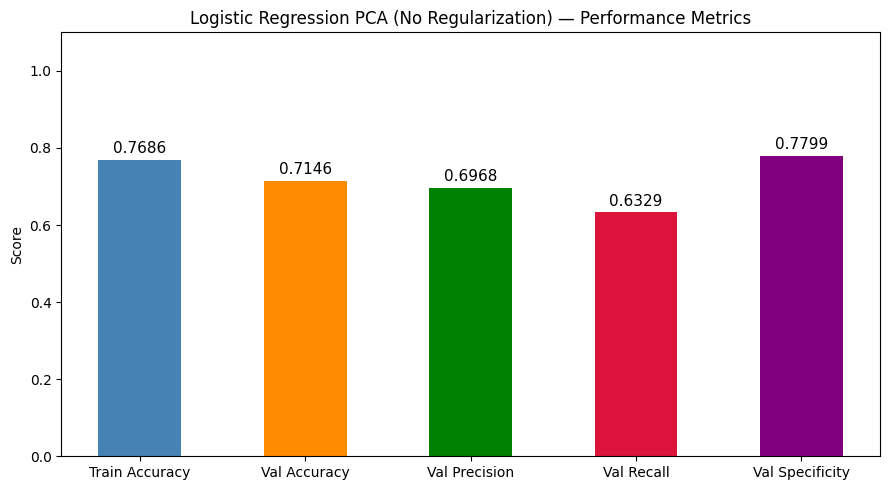

In [ ]:
# logistic with PCA
pca_final = PCA(n_components=n_95, random_state=42)
X_train_pca_final = pca_final.fit_transform(X_train_flat)
X_val_pca_final = pca_final.transform(X_val_flat)
X_test_pca_final = pca_final.transform(X_test_flat)

lr_pca_no_reg = LogisticRegression(penalty=None, max_iter=1000, random_state=42)
lr_pca_no_reg.fit(X_train_pca_final, y_train)

train_preds = lr_pca_no_reg.predict(X_train_pca_final)
val_preds = lr_pca_no_reg.predict(X_val_pca_final)

pca_no_reg_train_acc = accuracy_score(y_train, train_preds)
pca_no_reg_val_acc = accuracy_score(y_val, val_preds)
pca_no_reg_val_precision = precision_score(y_val, val_preds)
pca_no_reg_val_recall = recall_score(y_val, val_preds)
tn, fp, fn, tp = confusion_matrix(y_val, val_preds).ravel()
pca_no_reg_val_specificity = tn / (tn + fp)

metrics = [pca_no_reg_train_acc, pca_no_reg_val_acc, pca_no_reg_val_precision, pca_no_reg_val_recall, pca_no_reg_val_specificity]
labels = ['Train Accuracy', 'Val Accuracy', 'Val Precision', 'Val Recall', 'Val Specificity']
colors = ['steelblue', 'darkorange', 'green', 'crimson', 'purple']

plt.figure(figsize=(9, 5))
bars = plt.bar(labels, metrics, color=colors, width=0.5)
for bar, val in zip(bars, metrics):
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01, f'{val:.4f}', ha='center', va='bottom', fontsize=11)
plt.ylim(0, 1.1)
plt.ylabel('Score')
plt.title('Logistic Regression PCA (No Regularization) — Performance Metrics')
plt.tight_layout()
plt.show()

### 2.4 PCA Features — L2 Regularization Sweep

We apply L2 regularization on the PCA-reduced features across the same λ range.
Since PCA already reduces dimensionality significantly, we expect regularization to have a smaller effect here
compared to the raw-pixel case.

In [ ]:
pca_unregularized_metrics = {
    'train_acc': pca_no_reg_train_acc,
    'val_acc': pca_no_reg_val_acc,
    'val_precision': pca_no_reg_val_precision,
    'val_recall': pca_no_reg_val_recall,
    'val_specificity': pca_no_reg_val_specificity
}

pca_l2_metrics = []

for lam in lambda_values:
    model = LogisticRegression(penalty='l2', C=1/lam, max_iter=1000, random_state=42)
    model.fit(X_train_pca_final, y_train)

    train_preds = model.predict(X_train_pca_final)
    val_preds = model.predict(X_val_pca_final)

    t_acc = accuracy_score(y_train, train_preds)
    v_acc = accuracy_score(y_val, val_preds)
    v_prec = precision_score(y_val, val_preds)
    v_rec = recall_score(y_val, val_preds)
    tn, fp, fn, tp = confusion_matrix(y_val, val_preds).ravel()
    v_spec = tn / (tn + fp)

    pca_l2_metrics.append({
        'lambda': lam,
        'train_acc': t_acc,
        'val_acc': v_acc,
        'val_precision': v_prec,
        'val_recall': v_rec,
        'val_specificity': v_spec
    })

for m in pca_l2_metrics:
    print(f"λ={m['lambda']:>6} | Train Acc: {m['train_acc']:.4f} | Val Acc: {m['val_acc']:.4f} | "
          f"Precision: {m['val_precision']:.4f} | Recall: {m['val_recall']:.4f} | Specificity: {m['val_specificity']:.4f}")

λ=   0.1 | Train Acc: 0.7686 | Val Acc: 0.7146 | Precision: 0.6968 | Recall: 0.6329 | Specificity: 0.7799
λ=     1 | Train Acc: 0.7682 | Val Acc: 0.7146 | Precision: 0.6968 | Recall: 0.6329 | Specificity: 0.7799
λ=    10 | Train Acc: 0.7668 | Val Acc: 0.7253 | Precision: 0.7112 | Recall: 0.6425 | Specificity: 0.7915
λ=   100 | Train Acc: 0.7525 | Val Acc: 0.7232 | Precision: 0.7167 | Recall: 0.6232 | Specificity: 0.8031
λ=  1000 | Train Acc: 0.7162 | Val Acc: 0.7124 | Precision: 0.7212 | Recall: 0.5749 | Specificity: 0.8224
λ= 10000 | Train Acc: 0.6605 | Val Acc: 0.6545 | Precision: 0.6949 | Recall: 0.3961 | Specificity: 0.8610


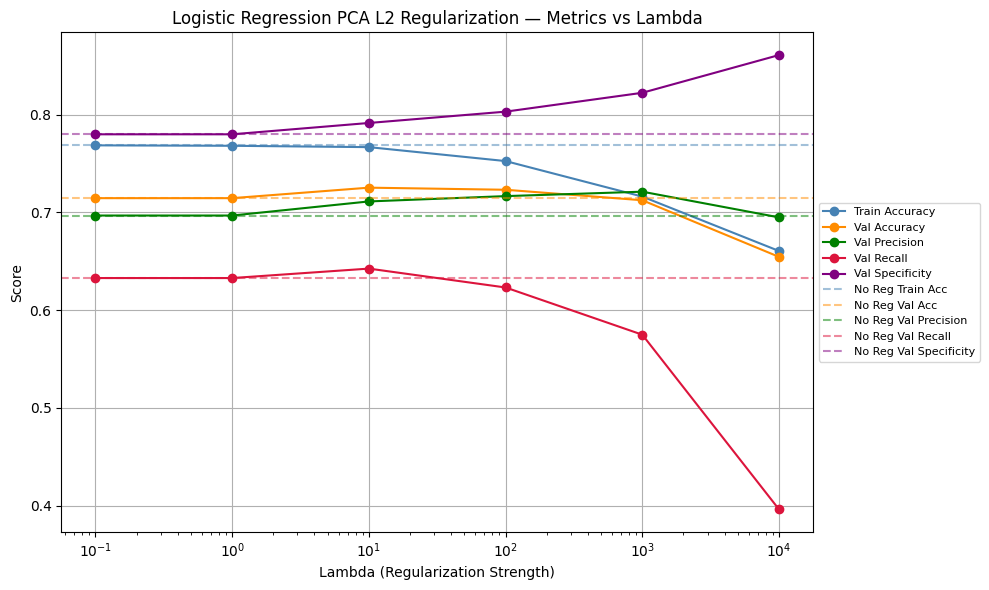

In [ ]:
pca_train_accs = [m['train_acc'] for m in pca_l2_metrics]
pca_val_accs = [m['val_acc'] for m in pca_l2_metrics]
pca_val_precs = [m['val_precision'] for m in pca_l2_metrics]
pca_val_recs = [m['val_recall'] for m in pca_l2_metrics]
pca_val_specs = [m['val_specificity'] for m in pca_l2_metrics]

plt.figure(figsize=(10, 6))
plt.plot(lambda_values, pca_train_accs, marker='o', color='steelblue', label='Train Accuracy')
plt.plot(lambda_values, pca_val_accs, marker='o', color='darkorange', label='Val Accuracy')
plt.plot(lambda_values, pca_val_precs, marker='o', color='green', label='Val Precision')
plt.plot(lambda_values, pca_val_recs, marker='o', color='crimson', label='Val Recall')
plt.plot(lambda_values, pca_val_specs, marker='o', color='purple', label='Val Specificity')

plt.axhline(y=pca_unregularized_metrics['train_acc'], color='steelblue', linestyle='--', alpha=0.5, label='No Reg Train Acc')
plt.axhline(y=pca_unregularized_metrics['val_acc'], color='darkorange', linestyle='--', alpha=0.5, label='No Reg Val Acc')
plt.axhline(y=pca_unregularized_metrics['val_precision'], color='green', linestyle='--', alpha=0.5, label='No Reg Val Precision')
plt.axhline(y=pca_unregularized_metrics['val_recall'], color='crimson', linestyle='--', alpha=0.5, label='No Reg Val Recall')
plt.axhline(y=pca_unregularized_metrics['val_specificity'], color='purple', linestyle='--', alpha=0.5, label='No Reg Val Specificity')

plt.xscale('log')
plt.xlabel('Lambda (Regularization Strength)')
plt.ylabel('Score')
plt.title('Logistic Regression PCA L2 Regularization — Metrics vs Lambda')
plt.legend(loc='center left', bbox_to_anchor=(1.0, 0.5), fontsize=8)
plt.grid(True)
plt.tight_layout()
plt.show()

### 2.5 PCA (top 50) + Degree-2 Polynomial Features — No Regularization

To capture **non-linear interactions** between features, we apply a degree-2 polynomial transformation
on the top **50 PCA components**.

This expands the feature space to include all pairwise products and squared terms,
resulting in `50 + C(50,2) + 50 = 1,325` features.

Polynomial expansion increases model capacity but also raises the risk of overfitting,
especially without regularization.

Polynomial feature shape: (2174, 1325)


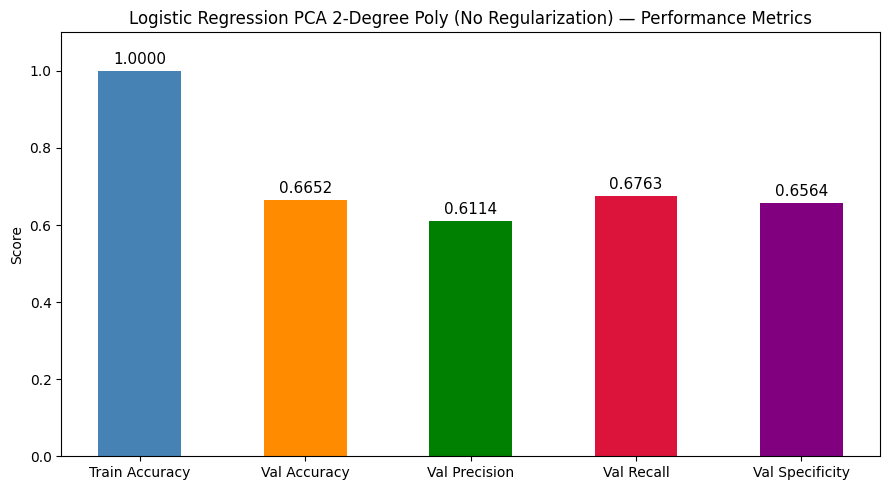

In [ ]:
# logistic with PC 1-50 and poly 2-degree transformation
from sklearn.preprocessing import PolynomialFeatures

pca_poly = PCA(n_components=50, random_state=42)
X_train_pca_poly = pca_poly.fit_transform(X_train_flat)
X_val_pca_poly = pca_poly.transform(X_val_flat)
X_test_pca_poly = pca_poly.transform(X_test_flat)

poly = PolynomialFeatures(degree=2, include_bias=False)
X_train_poly = poly.fit_transform(X_train_pca_poly)
X_val_poly = poly.transform(X_val_pca_poly)
X_test_poly = poly.transform(X_test_pca_poly)

print(f"Polynomial feature shape: {X_train_poly.shape}")

lr_poly_no_reg = LogisticRegression(penalty=None, max_iter=1000, random_state=42)
lr_poly_no_reg.fit(X_train_poly, y_train)

train_preds = lr_poly_no_reg.predict(X_train_poly)
val_preds = lr_poly_no_reg.predict(X_val_poly)

poly_no_reg_train_acc = accuracy_score(y_train, train_preds)
poly_no_reg_val_acc = accuracy_score(y_val, val_preds)
poly_no_reg_val_precision = precision_score(y_val, val_preds)
poly_no_reg_val_recall = recall_score(y_val, val_preds)
tn, fp, fn, tp = confusion_matrix(y_val, val_preds).ravel()
poly_no_reg_val_specificity = tn / (tn + fp)

metrics = [poly_no_reg_train_acc, poly_no_reg_val_acc, poly_no_reg_val_precision, poly_no_reg_val_recall, poly_no_reg_val_specificity]
labels = ['Train Accuracy', 'Val Accuracy', 'Val Precision', 'Val Recall', 'Val Specificity']
colors = ['steelblue', 'darkorange', 'green', 'crimson', 'purple']

plt.figure(figsize=(9, 5))
bars = plt.bar(labels, metrics, color=colors, width=0.5)
for bar, val in zip(bars, metrics):
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01, f'{val:.4f}', ha='center', va='bottom', fontsize=11)
plt.ylim(0, 1.1)
plt.ylabel('Score')
plt.title('Logistic Regression PCA 2-Degree Poly (No Regularization) — Performance Metrics')
plt.tight_layout()
plt.show()

### 2.6 PCA (top 50) + Degree-2 Polynomial — L2 Regularization Sweep

With the high-dimensional polynomial features (1,325-dim), regularization becomes more critical.
We sweep L2 λ values and observe how regularization controls overfitting in this expanded feature space.

In [ ]:
poly_unregularized_metrics = {
    'train_acc': poly_no_reg_train_acc,
    'val_acc': poly_no_reg_val_acc,
    'val_precision': poly_no_reg_val_precision,
    'val_recall': poly_no_reg_val_recall,
    'val_specificity': poly_no_reg_val_specificity
}

poly_l2_metrics = []

for lam in lambda_values:
    print(lam)
    model = LogisticRegression(penalty='l2', C=1/lam, max_iter=1000, random_state=42)
    model.fit(X_train_poly, y_train)

    train_preds = model.predict(X_train_poly)
    val_preds = model.predict(X_val_poly)

    t_acc = accuracy_score(y_train, train_preds)
    v_acc = accuracy_score(y_val, val_preds)
    v_prec = precision_score(y_val, val_preds)
    v_rec = recall_score(y_val, val_preds)
    tn, fp, fn, tp = confusion_matrix(y_val, val_preds).ravel()
    v_spec = tn / (tn + fp)

    poly_l2_metrics.append({
        'lambda': lam,
        'train_acc': t_acc,
        'val_acc': v_acc,
        'val_precision': v_prec,
        'val_recall': v_rec,
        'val_specificity': v_spec
    })

for m in poly_l2_metrics:
    print(f"λ={m['lambda']:>6} | Train Acc: {m['train_acc']:.4f} | Val Acc: {m['val_acc']:.4f} | "
          f"Precision: {m['val_precision']:.4f} | Recall: {m['val_recall']:.4f} | Specificity: {m['val_specificity']:.4f}")

0.1
1


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


10


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


100


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


1000
10000
λ=   0.1 | Train Acc: 1.0000 | Val Acc: 0.6588 | Precision: 0.6132 | Recall: 0.6280 | Specificity: 0.6834
λ=     1 | Train Acc: 1.0000 | Val Acc: 0.6567 | Precision: 0.6114 | Recall: 0.6232 | Specificity: 0.6834
λ=    10 | Train Acc: 1.0000 | Val Acc: 0.6588 | Precision: 0.6132 | Recall: 0.6280 | Specificity: 0.6834
λ=   100 | Train Acc: 0.9862 | Val Acc: 0.6652 | Precision: 0.6186 | Recall: 0.6425 | Specificity: 0.6834
λ=  1000 | Train Acc: 0.9218 | Val Acc: 0.6738 | Precision: 0.6329 | Recall: 0.6329 | Specificity: 0.7066
λ= 10000 | Train Acc: 0.8367 | Val Acc: 0.6738 | Precision: 0.6536 | Recall: 0.5652 | Specificity: 0.7606


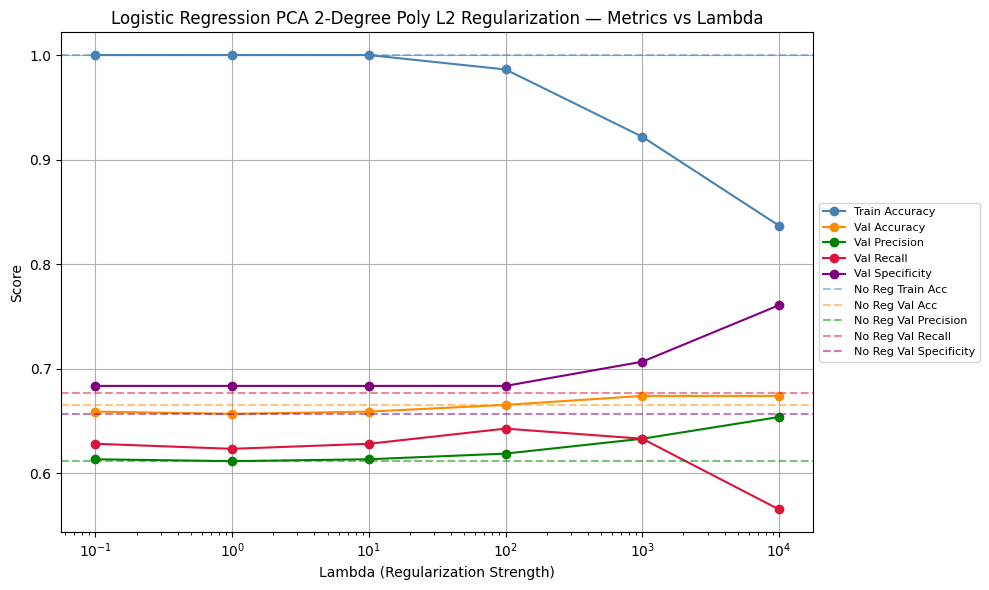

In [ ]:
poly_train_accs = [m['train_acc'] for m in poly_l2_metrics]
poly_val_accs = [m['val_acc'] for m in poly_l2_metrics]
poly_val_precs = [m['val_precision'] for m in poly_l2_metrics]
poly_val_recs = [m['val_recall'] for m in poly_l2_metrics]
poly_val_specs = [m['val_specificity'] for m in poly_l2_metrics]

plt.figure(figsize=(10, 6))
plt.plot(lambda_values, poly_train_accs, marker='o', color='steelblue', label='Train Accuracy')
plt.plot(lambda_values, poly_val_accs, marker='o', color='darkorange', label='Val Accuracy')
plt.plot(lambda_values, poly_val_precs, marker='o', color='green', label='Val Precision')
plt.plot(lambda_values, poly_val_recs, marker='o', color='crimson', label='Val Recall')
plt.plot(lambda_values, poly_val_specs, marker='o', color='purple', label='Val Specificity')

plt.axhline(y=poly_unregularized_metrics['train_acc'], color='steelblue', linestyle='--', alpha=0.5, label='No Reg Train Acc')
plt.axhline(y=poly_unregularized_metrics['val_acc'], color='darkorange', linestyle='--', alpha=0.5, label='No Reg Val Acc')
plt.axhline(y=poly_unregularized_metrics['val_precision'], color='green', linestyle='--', alpha=0.5, label='No Reg Val Precision')
plt.axhline(y=poly_unregularized_metrics['val_recall'], color='crimson', linestyle='--', alpha=0.5, label='No Reg Val Recall')
plt.axhline(y=poly_unregularized_metrics['val_specificity'], color='purple', linestyle='--', alpha=0.5, label='No Reg Val Specificity')

plt.xscale('log')
plt.xlabel('Lambda (Regularization Strength)')
plt.ylabel('Score')
plt.title('Logistic Regression PCA 2-Degree Poly L2 Regularization — Metrics vs Lambda')
plt.legend(loc='center left', bbox_to_anchor=(1.0, 0.5), fontsize=8)
plt.grid(True)
plt.tight_layout()
plt.show()

### 2.7 PCA (top 25) + Degree-2 Polynomial Features — No Regularization

As a variant, we reduce the number of PCA components to **25** before polynomial expansion,
yielding a smaller feature space (~325 features).

This trades off some expressive power for a lower-dimensional representation,
which may generalize better without needing as strong a regularizer.

Polynomial feature shape: (2174, 350)


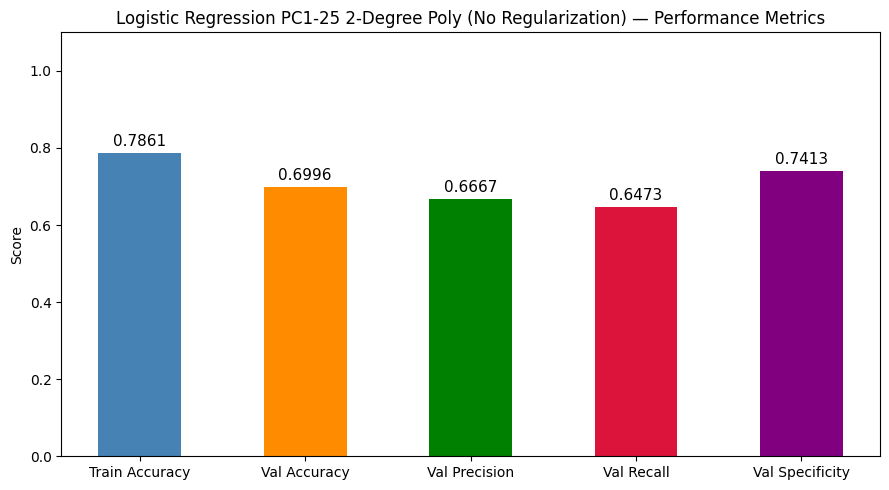

In [ ]:
pca_poly25 = PCA(n_components=25, random_state=42)
X_train_pca_poly25 = pca_poly25.fit_transform(X_train_flat)
X_val_pca_poly25 = pca_poly25.transform(X_val_flat)
X_test_pca_poly25 = pca_poly25.transform(X_test_flat)

poly25 = PolynomialFeatures(degree=2, include_bias=False)
X_train_poly25 = poly25.fit_transform(X_train_pca_poly25)
X_val_poly25 = poly25.transform(X_val_pca_poly25)
X_test_poly25 = poly25.transform(X_test_pca_poly25)

print(f"Polynomial feature shape: {X_train_poly25.shape}")

lr_poly25_no_reg = LogisticRegression(penalty=None, max_iter=1000, random_state=42)
lr_poly25_no_reg.fit(X_train_poly25, y_train)

train_preds = lr_poly25_no_reg.predict(X_train_poly25)
val_preds = lr_poly25_no_reg.predict(X_val_poly25)

poly25_no_reg_train_acc = accuracy_score(y_train, train_preds)
poly25_no_reg_val_acc = accuracy_score(y_val, val_preds)
poly25_no_reg_val_precision = precision_score(y_val, val_preds)
poly25_no_reg_val_recall = recall_score(y_val, val_preds)
tn, fp, fn, tp = confusion_matrix(y_val, val_preds).ravel()
poly25_no_reg_val_specificity = tn / (tn + fp)

metrics = [poly25_no_reg_train_acc, poly25_no_reg_val_acc, poly25_no_reg_val_precision, poly25_no_reg_val_recall, poly25_no_reg_val_specificity]
labels = ['Train Accuracy', 'Val Accuracy', 'Val Precision', 'Val Recall', 'Val Specificity']
colors = ['steelblue', 'darkorange', 'green', 'crimson', 'purple']

plt.figure(figsize=(9, 5))
bars = plt.bar(labels, metrics, color=colors, width=0.5)
for bar, val in zip(bars, metrics):
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01, f'{val:.4f}', ha='center', va='bottom', fontsize=11)
plt.ylim(0, 1.1)
plt.ylabel('Score')
plt.title('Logistic Regression PC1-25 2-Degree Poly (No Regularization) — Performance Metrics')
plt.tight_layout()
plt.show()

### 2.8 PCA (top 25) + Degree-2 Polynomial — L2 Regularization Sweep

Same L2 sweep as before, now applied to the more compact PCA-25 + polynomial feature set.
Comparing with 2.6 lets us see how the number of PCA components affects the regularization tradeoff.

In [ ]:
poly25_unregularized_metrics = {
    'train_acc': poly25_no_reg_train_acc,
    'val_acc': poly25_no_reg_val_acc,
    'val_precision': poly25_no_reg_val_precision,
    'val_recall': poly25_no_reg_val_recall,
    'val_specificity': poly25_no_reg_val_specificity
}

poly25_l2_metrics = []

for lam in lambda_values:
    print(lam)
    model = LogisticRegression(penalty='l2', C=1/lam, max_iter=1000, random_state=42)
    model.fit(X_train_poly25, y_train)

    train_preds = model.predict(X_train_poly25)
    val_preds = model.predict(X_val_poly25)

    t_acc = accuracy_score(y_train, train_preds)
    v_acc = accuracy_score(y_val, val_preds)
    v_prec = precision_score(y_val, val_preds)
    v_rec = recall_score(y_val, val_preds)
    tn, fp, fn, tp = confusion_matrix(y_val, val_preds).ravel()
    v_spec = tn / (tn + fp)

    poly25_l2_metrics.append({
        'lambda': lam,
        'train_acc': t_acc,
        'val_acc': v_acc,
        'val_precision': v_prec,
        'val_recall': v_rec,
        'val_specificity': v_spec
    })

for m in poly25_l2_metrics:
    print(f"λ={m['lambda']:>6} | Train Acc: {m['train_acc']:.4f} | Val Acc: {m['val_acc']:.4f} | "
          f"Precision: {m['val_precision']:.4f} | Recall: {m['val_recall']:.4f} | Specificity: {m['val_specificity']:.4f}")

0.1
1


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


10


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


100
1000
10000
λ=   0.1 | Train Acc: 0.7861 | Val Acc: 0.6996 | Precision: 0.6667 | Recall: 0.6473 | Specificity: 0.7413
λ=     1 | Train Acc: 0.7866 | Val Acc: 0.6996 | Precision: 0.6667 | Recall: 0.6473 | Specificity: 0.7413
λ=    10 | Train Acc: 0.7861 | Val Acc: 0.6953 | Precision: 0.6601 | Recall: 0.6473 | Specificity: 0.7336
λ=   100 | Train Acc: 0.7847 | Val Acc: 0.6996 | Precision: 0.6650 | Recall: 0.6522 | Specificity: 0.7375
λ=  1000 | Train Acc: 0.7769 | Val Acc: 0.6931 | Precision: 0.6720 | Recall: 0.6039 | Specificity: 0.7645
λ= 10000 | Train Acc: 0.7410 | Val Acc: 0.6888 | Precision: 0.6782 | Recall: 0.5700 | Specificity: 0.7838


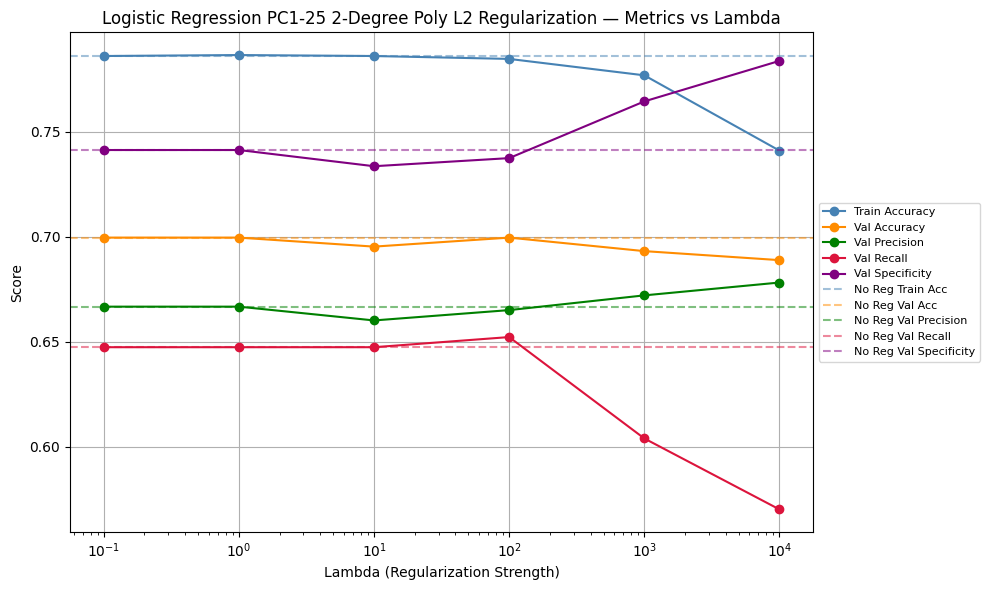

In [ ]:
poly25_train_accs = [m['train_acc'] for m in poly25_l2_metrics]
poly25_val_accs = [m['val_acc'] for m in poly25_l2_metrics]
poly25_val_precs = [m['val_precision'] for m in poly25_l2_metrics]
poly25_val_recs = [m['val_recall'] for m in poly25_l2_metrics]
poly25_val_specs = [m['val_specificity'] for m in poly25_l2_metrics]

plt.figure(figsize=(10, 6))
plt.plot(lambda_values, poly25_train_accs, marker='o', color='steelblue', label='Train Accuracy')
plt.plot(lambda_values, poly25_val_accs, marker='o', color='darkorange', label='Val Accuracy')
plt.plot(lambda_values, poly25_val_precs, marker='o', color='green', label='Val Precision')
plt.plot(lambda_values, poly25_val_recs, marker='o', color='crimson', label='Val Recall')
plt.plot(lambda_values, poly25_val_specs, marker='o', color='purple', label='Val Specificity')

plt.axhline(y=poly25_unregularized_metrics['train_acc'], color='steelblue', linestyle='--', alpha=0.5, label='No Reg Train Acc')
plt.axhline(y=poly25_unregularized_metrics['val_acc'], color='darkorange', linestyle='--', alpha=0.5, label='No Reg Val Acc')
plt.axhline(y=poly25_unregularized_metrics['val_precision'], color='green', linestyle='--', alpha=0.5, label='No Reg Val Precision')
plt.axhline(y=poly25_unregularized_metrics['val_recall'], color='crimson', linestyle='--', alpha=0.5, label='No Reg Val Recall')
plt.axhline(y=poly25_unregularized_metrics['val_specificity'], color='purple', linestyle='--', alpha=0.5, label='No Reg Val Specificity')

plt.xscale('log')
plt.xlabel('Lambda (Regularization Strength)')
plt.ylabel('Score')
plt.title('Logistic Regression PC1-25 2-Degree Poly L2 Regularization — Metrics vs Lambda')
plt.legend(loc='center left', bbox_to_anchor=(1.0, 0.5), fontsize=8)
plt.grid(True)
plt.tight_layout()
plt.show()

## 3. Neural Network (Fully Connected)

In this section, we train fully connected **Multi-Layer Perceptrons (MLPs)** for binary classification.
We experiment with different architectures and input representations, and for each we sweep over
**L2 weight decay** and **Dropout** to study regularization effects.

All models are trained with:
- **Optimizer:** Adam (lr = 0.001)
- **Loss:** Binary Cross-Entropy (BCELoss)
- **Epochs:** 50, batch size 32
- **Output activation:** Sigmoid → threshold at 0.5 for binary prediction

The architectures and input types explored are:

| Model | Input | Architecture |
|---|---|---|
| 3.1 Baseline | Raw pixels (12,288) | 12288 → 256 → 1 |
| 3.2 Wide | Raw pixels (12,288) | 12288 → 512 → 256 → 1 |
| 3.3 Narrow | Raw pixels (12,288) | 12288 → 256 → 128 → 1 |
| 3.4 PCA-Large | PCA (n_95 dims) | n_95 → 128 → 1 |
| 3.5 PCA-Small | PCA (n_95 dims) | n_95 → 32 → 1 |

Regularization grid: L2 ∈ {0, 0.0001, 0.001, 0.005} × Dropout ∈ {0, 0.1, 0.3}

### 3.1 Baseline MLP: 12288 → 256 → 1 (No Regularization)

We start with a simple single-hidden-layer network as a baseline.
Raw pixel inputs (12,288-dim) are fed into a hidden layer of **256 neurons with ReLU**,
followed by a **sigmoid output** for binary classification.

This unregularized baseline is expected to overfit given the high input dimensionality
relative to the training set size.

Epoch 10/50 complete
Epoch 20/50 complete
Epoch 30/50 complete
Epoch 40/50 complete
Epoch 50/50 complete


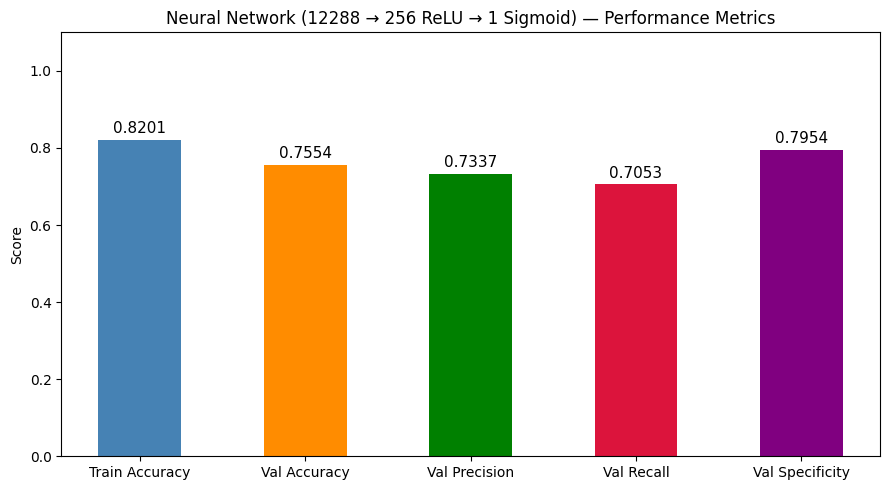

In [ ]:
# NN 12288 - 256 ReLU – 1 sigmoid
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

X_train_tensor = torch.tensor(X_train_flat, dtype=torch.float32)
X_val_tensor = torch.tensor(X_val_flat, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32)
y_val_tensor = torch.tensor(y_val, dtype=torch.float32)

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)

class NN_256(nn.Module):
    def __init__(self):
        super(NN_256, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(12288, 256),
            nn.ReLU(),
            nn.Linear(256, 1),
            nn.Sigmoid()
        )
    def forward(self, x):
        return self.net(x)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model_nn = NN_256().to(device)
criterion = nn.BCELoss()
optimizer = torch.optim.Adam(model_nn.parameters(), lr=0.001)

epochs = 50
for epoch in range(epochs):
    model_nn.train()
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        optimizer.zero_grad()
        preds = model_nn(X_batch).squeeze()
        loss = criterion(preds, y_batch)
        loss.backward()
        optimizer.step()
    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1}/{epochs} complete")

model_nn.eval()
with torch.no_grad():
    train_preds = (model_nn(X_train_tensor.to(device)).squeeze().cpu().numpy() >= 0.5).astype(int)
    val_preds = (model_nn(X_val_tensor.to(device)).squeeze().cpu().numpy() >= 0.5).astype(int)

nn_train_acc = accuracy_score(y_train, train_preds)
nn_val_acc = accuracy_score(y_val, val_preds)
nn_val_precision = precision_score(y_val, val_preds)
nn_val_recall = recall_score(y_val, val_preds)
tn, fp, fn, tp = confusion_matrix(y_val, val_preds).ravel()
nn_val_specificity = tn / (tn + fp)

metrics = [nn_train_acc, nn_val_acc, nn_val_precision, nn_val_recall, nn_val_specificity]
labels = ['Train Accuracy', 'Val Accuracy', 'Val Precision', 'Val Recall', 'Val Specificity']
colors = ['steelblue', 'darkorange', 'green', 'crimson', 'purple']

plt.figure(figsize=(9, 5))
bars = plt.bar(labels, metrics, color=colors, width=0.5)
for bar, val in zip(bars, metrics):
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01, f'{val:.4f}', ha='center', va='bottom', fontsize=11)
plt.ylim(0, 1.1)
plt.ylabel('Score')
plt.title('Neural Network (12288 → 256 ReLU → 1 Sigmoid) — Performance Metrics')
plt.tight_layout()
plt.show()

### 3.2 Baseline MLP — L2 Weight Decay & Dropout Sweep

We now apply regularization to the same 12288 → 256 → 1 architecture,
sweeping over all combinations of **L2 weight decay** and **Dropout rate**.

- **L2 weight decay** is applied via the `weight_decay` argument in the Adam optimizer,
  penalizing large weights globally.
- **Dropout** randomly zeros out a fraction of neurons during training,
  acting as an implicit ensemble and preventing co-adaptation of features.

Comparing these 12 configurations (4 L2 × 3 Dropout) reveals how each regularizer
and their combination affect the bias-variance tradeoff.

In [ ]:
l2_values = [0, 0.0001, 0.001, 0.005]
dropout_values = [0, 0.1, 0.3]

nn_reg_metrics = []

for l2 in l2_values:
    for dropout in dropout_values:
        class NN_Reg(nn.Module):
            def __init__(self, dropout_rate):
                super(NN_Reg, self).__init__()
                self.net = nn.Sequential(
                    nn.Linear(12288, 256),
                    nn.ReLU(),
                    nn.Dropout(dropout_rate),
                    nn.Linear(256, 1),
                    nn.Sigmoid()
                )
            def forward(self, x):
                return self.net(x)

        model_reg = NN_Reg(dropout).to(device)
        optimizer_reg = torch.optim.Adam(model_reg.parameters(), lr=0.001, weight_decay=l2)

        for epoch in range(epochs):
            model_reg.train()
            for X_batch, y_batch in train_loader:
                X_batch, y_batch = X_batch.to(device), y_batch.to(device)
                optimizer_reg.zero_grad()
                preds = model_reg(X_batch).squeeze()
                loss = criterion(preds, y_batch)
                loss.backward()
                optimizer_reg.step()

        model_reg.eval()
        with torch.no_grad():
            train_preds = (model_reg(X_train_tensor.to(device)).squeeze().cpu().numpy() >= 0.5).astype(int)
            val_preds = (model_reg(X_val_tensor.to(device)).squeeze().cpu().numpy() >= 0.5).astype(int)

        t_acc = accuracy_score(y_train, train_preds)
        v_acc = accuracy_score(y_val, val_preds)
        v_prec = precision_score(y_val, val_preds)
        v_rec = recall_score(y_val, val_preds)
        tn, fp, fn, tp = confusion_matrix(y_val, val_preds).ravel()
        v_spec = tn / (tn + fp)

        nn_reg_metrics.append({
            'l2': l2,
            'dropout': dropout,
            'train_acc': t_acc,
            'val_acc': v_acc,
            'val_precision': v_prec,
            'val_recall': v_rec,
            'val_specificity': v_spec
        })

        print(f"L2={l2} | Dropout={dropout} | Train Acc: {t_acc:.4f} | Val Acc: {v_acc:.4f} | "
              f"Precision: {v_prec:.4f} | Recall: {v_rec:.4f} | Specificity: {v_spec:.4f}")

L2=0 | Dropout=0 | Train Acc: 0.7971 | Val Acc: 0.7425 | Precision: 0.7486 | Recall: 0.6329 | Specificity: 0.8301
L2=0 | Dropout=0.1 | Train Acc: 0.7590 | Val Acc: 0.6867 | Precision: 0.6125 | Recall: 0.8019 | Specificity: 0.5946
L2=0 | Dropout=0.3 | Train Acc: 0.7534 | Val Acc: 0.7189 | Precision: 0.7043 | Recall: 0.6329 | Specificity: 0.7876
L2=0.0001 | Dropout=0 | Train Acc: 0.7626 | Val Acc: 0.7124 | Precision: 0.7325 | Recall: 0.5556 | Specificity: 0.8378
L2=0.0001 | Dropout=0.1 | Train Acc: 0.7130 | Val Acc: 0.6738 | Precision: 0.7895 | Recall: 0.3623 | Specificity: 0.9228
L2=0.0001 | Dropout=0.3 | Train Acc: 0.7351 | Val Acc: 0.7060 | Precision: 0.7574 | Recall: 0.4976 | Specificity: 0.8726
L2=0.001 | Dropout=0 | Train Acc: 0.7879 | Val Acc: 0.7361 | Precision: 0.7727 | Recall: 0.5749 | Specificity: 0.8649
L2=0.001 | Dropout=0.1 | Train Acc: 0.7521 | Val Acc: 0.7167 | Precision: 0.6728 | Recall: 0.7053 | Specificity: 0.7259
L2=0.001 | Dropout=0.3 | Train Acc: 0.7452 | Val Acc: 0

### 3.3 Wider MLP: 12288 → 512 → 256 → 1

We increase model capacity by adding a second hidden layer and widening the network:
**512 → 256 hidden units**, each followed by ReLU and Dropout.

A wider, deeper network has more parameters and can learn more complex decision boundaries,
but is also more prone to overfitting — making regularization more important.
We apply the same L2 × Dropout grid as in 3.2.

In [ ]:
# 12288-512-256-1
l2_values = [0, 0.0001, 0.001, 0.005]
dropout_values = [0, 0.1, 0.3]

nn_512_256_metrics = []

for l2 in l2_values:
    for dropout in dropout_values:
        class NN_512_256(nn.Module):
            def __init__(self, dropout_rate):
                super(NN_512_256, self).__init__()
                self.net = nn.Sequential(
                    nn.Linear(12288, 512),
                    nn.ReLU(),
                    nn.Dropout(dropout_rate),
                    nn.Linear(512, 256),
                    nn.ReLU(),
                    nn.Dropout(dropout_rate),
                    nn.Linear(256, 1),
                    nn.Sigmoid()
                )
            def forward(self, x):
                return self.net(x)

        model_reg = NN_512_256(dropout).to(device)
        optimizer_reg = torch.optim.Adam(model_reg.parameters(), lr=0.001, weight_decay=l2)

        for epoch in range(epochs):
            model_reg.train()
            for X_batch, y_batch in train_loader:
                X_batch, y_batch = X_batch.to(device), y_batch.to(device)
                optimizer_reg.zero_grad()
                preds = model_reg(X_batch).squeeze()
                loss = criterion(preds, y_batch)
                loss.backward()
                optimizer_reg.step()

        model_reg.eval()
        with torch.no_grad():
            train_preds = (model_reg(X_train_tensor.to(device)).squeeze().cpu().numpy() >= 0.5).astype(int)
            val_preds = (model_reg(X_val_tensor.to(device)).squeeze().cpu().numpy() >= 0.5).astype(int)

        t_acc = accuracy_score(y_train, train_preds)
        v_acc = accuracy_score(y_val, val_preds)
        v_prec = precision_score(y_val, val_preds, zero_division=0)
        v_rec = recall_score(y_val, val_preds, zero_division=0)
        tn, fp, fn, tp = confusion_matrix(y_val, val_preds).ravel()
        v_spec = tn / (tn + fp)

        nn_512_256_metrics.append({
            'l2': l2,
            'dropout': dropout,
            'train_acc': t_acc,
            'val_acc': v_acc,
            'val_precision': v_prec,
            'val_recall': v_rec,
            'val_specificity': v_spec
        })

        print(f"L2={l2} | Dropout={dropout} | Train Acc: {t_acc:.4f} | Val Acc: {v_acc:.4f} | "
              f"Precision: {v_prec:.4f} | Recall: {v_rec:.4f} | Specificity: {v_spec:.4f}")

L2=0 | Dropout=0 | Train Acc: 0.8031 | Val Acc: 0.7232 | Precision: 0.6912 | Recall: 0.6812 | Specificity: 0.7568
L2=0 | Dropout=0.1 | Train Acc: 0.6762 | Val Acc: 0.6266 | Precision: 0.5487 | Recall: 0.8986 | Specificity: 0.4093
L2=0 | Dropout=0.3 | Train Acc: 0.7148 | Val Acc: 0.6738 | Precision: 0.7957 | Recall: 0.3575 | Specificity: 0.9266
L2=0.0001 | Dropout=0 | Train Acc: 0.8183 | Val Acc: 0.7082 | Precision: 0.6498 | Recall: 0.7440 | Specificity: 0.6795
L2=0.0001 | Dropout=0.1 | Train Acc: 0.7507 | Val Acc: 0.7124 | Precision: 0.6527 | Recall: 0.7536 | Specificity: 0.6795
L2=0.0001 | Dropout=0.3 | Train Acc: 0.7162 | Val Acc: 0.7039 | Precision: 0.6561 | Recall: 0.7005 | Specificity: 0.7066
L2=0.001 | Dropout=0 | Train Acc: 0.7213 | Val Acc: 0.6781 | Precision: 0.7879 | Recall: 0.3768 | Specificity: 0.9189
L2=0.001 | Dropout=0.1 | Train Acc: 0.7466 | Val Acc: 0.6781 | Precision: 0.6029 | Recall: 0.8068 | Specificity: 0.5753
L2=0.001 | Dropout=0.3 | Train Acc: 0.7590 | Val Acc: 0

### 3.4 Narrower MLP: 12288 → 256 → 128 → 1

As a contrast to 3.3, we test a narrower two-hidden-layer network: **256 → 128 units**.
This has fewer parameters, which may generalize better but could underfit
if the task requires more representational capacity.

Same regularization grid is applied for a fair comparison.

In [ ]:
# 12288-256-128-1
l2_values = [0, 0.0001, 0.001, 0.005]
dropout_values = [0, 0.1, 0.3]

nn_256_128_metrics = []

for l2 in l2_values:
    for dropout in dropout_values:
        class NN_256_128(nn.Module):
            def __init__(self, dropout_rate):
                super(NN_256_128, self).__init__()
                self.net = nn.Sequential(
                    nn.Linear(12288, 256),
                    nn.ReLU(),
                    nn.Dropout(dropout_rate),
                    nn.Linear(256, 128),
                    nn.ReLU(),
                    nn.Dropout(dropout_rate),
                    nn.Linear(128, 1),
                    nn.Sigmoid()
                )
            def forward(self, x):
                return self.net(x)

        model_reg = NN_256_128(dropout).to(device)
        optimizer_reg = torch.optim.Adam(model_reg.parameters(), lr=0.001, weight_decay=l2)

        for epoch in range(epochs):
            model_reg.train()
            for X_batch, y_batch in train_loader:
                X_batch, y_batch = X_batch.to(device), y_batch.to(device)
                optimizer_reg.zero_grad()
                preds = model_reg(X_batch).squeeze()
                loss = criterion(preds, y_batch)
                loss.backward()
                optimizer_reg.step()

        model_reg.eval()
        with torch.no_grad():
            train_preds = (model_reg(X_train_tensor.to(device)).squeeze().cpu().numpy() >= 0.5).astype(int)
            val_preds = (model_reg(X_val_tensor.to(device)).squeeze().cpu().numpy() >= 0.5).astype(int)

        t_acc = accuracy_score(y_train, train_preds)
        v_acc = accuracy_score(y_val, val_preds)
        v_prec = precision_score(y_val, val_preds, zero_division=0)
        v_rec = recall_score(y_val, val_preds, zero_division=0)
        tn, fp, fn, tp = confusion_matrix(y_val, val_preds).ravel()
        v_spec = tn / (tn + fp)

        nn_256_128_metrics.append({
            'l2': l2,
            'dropout': dropout,
            'train_acc': t_acc,
            'val_acc': v_acc,
            'val_precision': v_prec,
            'val_recall': v_rec,
            'val_specificity': v_spec
        })

        print(f"L2={l2} | Dropout={dropout} | Train Acc: {t_acc:.4f} | Val Acc: {v_acc:.4f} | "
              f"Precision: {v_prec:.4f} | Recall: {v_rec:.4f} | Specificity: {v_spec:.4f}")

L2=0 | Dropout=0 | Train Acc: 0.8091 | Val Acc: 0.7597 | Precision: 0.7654 | Recall: 0.6618 | Specificity: 0.8378
L2=0 | Dropout=0.1 | Train Acc: 0.7774 | Val Acc: 0.6910 | Precision: 0.6226 | Recall: 0.7729 | Specificity: 0.6255
L2=0 | Dropout=0.3 | Train Acc: 0.7498 | Val Acc: 0.7232 | Precision: 0.7216 | Recall: 0.6135 | Specificity: 0.8108
L2=0.0001 | Dropout=0 | Train Acc: 0.8252 | Val Acc: 0.7425 | Precision: 0.6951 | Recall: 0.7488 | Specificity: 0.7375
L2=0.0001 | Dropout=0.1 | Train Acc: 0.7925 | Val Acc: 0.7103 | Precision: 0.6622 | Recall: 0.7101 | Specificity: 0.7104
L2=0.0001 | Dropout=0.3 | Train Acc: 0.7470 | Val Acc: 0.7253 | Precision: 0.7135 | Recall: 0.6377 | Specificity: 0.7954
L2=0.001 | Dropout=0 | Train Acc: 0.7185 | Val Acc: 0.6738 | Precision: 0.7778 | Recall: 0.3720 | Specificity: 0.9151
L2=0.001 | Dropout=0.1 | Train Acc: 0.7305 | Val Acc: 0.7146 | Precision: 0.7643 | Recall: 0.5169 | Specificity: 0.8726
L2=0.001 | Dropout=0.3 | Train Acc: 0.7222 | Val Acc: 0

### 3.5 PCA Input MLP: n_95 → 128 → 1

Instead of raw pixels, we switch to **PCA-compressed inputs** (top `n_95` components
retaining 95% of variance). The reduced dimensionality means far fewer input weights,
which should naturally reduce overfitting even before regularization.

This architecture tests whether a compact PCA representation paired with a moderate
hidden layer (128 units) can match or exceed the raw-pixel MLPs.

In [ ]:
# PCA 95-32-1
l2_values = [0, 0.0001, 0.001, 0.005]
dropout_values = [0, 0.1, 0.3]

nn_pca_128_metrics = []

X_train_pca_tensor = torch.tensor(X_train_pca_final, dtype=torch.float32)
X_val_pca_tensor = torch.tensor(X_val_pca_final, dtype=torch.float32)

pca_train_dataset = TensorDataset(X_train_pca_tensor, y_train_tensor)
pca_train_loader = DataLoader(pca_train_dataset, batch_size=32, shuffle=True)

for l2 in l2_values:
    for dropout in dropout_values:
        class NN_PCA_128(nn.Module):
            def __init__(self, dropout_rate):
                super(NN_PCA_128, self).__init__()
                self.net = nn.Sequential(
                    nn.Linear(n_95, 128),
                    nn.ReLU(),
                    nn.Dropout(dropout_rate),
                    nn.Linear(128, 1),
                    nn.Sigmoid()
                )
            def forward(self, x):
                return self.net(x)

        model_reg = NN_PCA_128(dropout).to(device)
        optimizer_reg = torch.optim.Adam(model_reg.parameters(), lr=0.001, weight_decay=l2)

        for epoch in range(epochs):
            model_reg.train()
            for X_batch, y_batch in pca_train_loader:
                X_batch, y_batch = X_batch.to(device), y_batch.to(device)
                optimizer_reg.zero_grad()
                preds = model_reg(X_batch).squeeze()
                loss = criterion(preds, y_batch)
                loss.backward()
                optimizer_reg.step()

        model_reg.eval()
        with torch.no_grad():
            train_preds = (model_reg(X_train_pca_tensor.to(device)).squeeze().cpu().numpy() >= 0.5).astype(int)
            val_preds = (model_reg(X_val_pca_tensor.to(device)).squeeze().cpu().numpy() >= 0.5).astype(int)

        t_acc = accuracy_score(y_train, train_preds)
        v_acc = accuracy_score(y_val, val_preds)
        v_prec = precision_score(y_val, val_preds, zero_division=0)
        v_rec = recall_score(y_val, val_preds, zero_division=0)
        tn, fp, fn, tp = confusion_matrix(y_val, val_preds).ravel()
        v_spec = tn / (tn + fp)

        nn_pca_128_metrics.append({
            'l2': l2,
            'dropout': dropout,
            'train_acc': t_acc,
            'val_acc': v_acc,
            'val_precision': v_prec,
            'val_recall': v_rec,
            'val_specificity': v_spec
        })

        print(f"L2={l2} | Dropout={dropout} | Train Acc: {t_acc:.4f} | Val Acc: {v_acc:.4f} | "
              f"Precision: {v_prec:.4f} | Recall: {v_rec:.4f} | Specificity: {v_spec:.4f}")

L2=0 | Dropout=0 | Train Acc: 1.0000 | Val Acc: 0.7511 | Precision: 0.7407 | Recall: 0.6763 | Specificity: 0.8108
L2=0 | Dropout=0.1 | Train Acc: 1.0000 | Val Acc: 0.7446 | Precision: 0.7245 | Recall: 0.6860 | Specificity: 0.7915
L2=0 | Dropout=0.3 | Train Acc: 0.9995 | Val Acc: 0.7318 | Precision: 0.7204 | Recall: 0.6473 | Specificity: 0.7992
L2=0.0001 | Dropout=0 | Train Acc: 1.0000 | Val Acc: 0.7189 | Precision: 0.6827 | Recall: 0.6860 | Specificity: 0.7452
L2=0.0001 | Dropout=0.1 | Train Acc: 0.9995 | Val Acc: 0.7275 | Precision: 0.7020 | Recall: 0.6715 | Specificity: 0.7722
L2=0.0001 | Dropout=0.3 | Train Acc: 1.0000 | Val Acc: 0.7468 | Precision: 0.7129 | Recall: 0.7198 | Specificity: 0.7683
L2=0.001 | Dropout=0 | Train Acc: 0.9885 | Val Acc: 0.7253 | Precision: 0.6985 | Recall: 0.6715 | Specificity: 0.7683
L2=0.001 | Dropout=0.1 | Train Acc: 1.0000 | Val Acc: 0.7146 | Precision: 0.6947 | Recall: 0.6377 | Specificity: 0.7761
L2=0.001 | Dropout=0.3 | Train Acc: 1.0000 | Val Acc: 0

### 3.6 PCA Input MLP: n_95 → 32 → 1

A more compact variant using PCA inputs with only **32 hidden units**.
This is the smallest network in the section — high bias, low variance.

Comparing 3.5 and 3.6 on the same PCA inputs isolates the effect of hidden layer width,
while comparing both against 3.3 and 3.4 shows the impact of input representation
(raw pixels vs. PCA) on generalization.

In [ ]:
l2_values = [0, 0.0001, 0.001, 0.005]
dropout_values = [0, 0.1, 0.3]

nn_pca_32_metrics = []

for l2 in l2_values:
    for dropout in dropout_values:
        class NN_PCA_32(nn.Module):
            def __init__(self, dropout_rate):
                super(NN_PCA_32, self).__init__()
                self.net = nn.Sequential(
                    nn.Linear(n_95, 32),
                    nn.ReLU(),
                    nn.Dropout(dropout_rate),
                    nn.Linear(32, 1),
                    nn.Sigmoid()
                )
            def forward(self, x):
                return self.net(x)

        model_reg = NN_PCA_32(dropout).to(device)
        optimizer_reg = torch.optim.Adam(model_reg.parameters(), lr=0.001, weight_decay=l2)

        for epoch in range(epochs):
            model_reg.train()
            for X_batch, y_batch in pca_train_loader:
                X_batch, y_batch = X_batch.to(device), y_batch.to(device)
                optimizer_reg.zero_grad()
                preds = model_reg(X_batch).squeeze()
                loss = criterion(preds, y_batch)
                loss.backward()
                optimizer_reg.step()

        model_reg.eval()
        with torch.no_grad():
            train_preds = (model_reg(X_train_pca_tensor.to(device)).squeeze().cpu().numpy() >= 0.5).astype(int)
            val_preds = (model_reg(X_val_pca_tensor.to(device)).squeeze().cpu().numpy() >= 0.5).astype(int)

        t_acc = accuracy_score(y_train, train_preds)
        v_acc = accuracy_score(y_val, val_preds)
        v_prec = precision_score(y_val, val_preds, zero_division=0)
        v_rec = recall_score(y_val, val_preds, zero_division=0)
        tn, fp, fn, tp = confusion_matrix(y_val, val_preds).ravel()
        v_spec = tn / (tn + fp)

        nn_pca_32_metrics.append({
            'l2': l2,
            'dropout': dropout,
            'train_acc': t_acc,
            'val_acc': v_acc,
            'val_precision': v_prec,
            'val_recall': v_rec,
            'val_specificity': v_spec
        })

        print(f"L2={l2} | Dropout={dropout} | Train Acc: {t_acc:.4f} | Val Acc: {v_acc:.4f} | "
              f"Precision: {v_prec:.4f} | Recall: {v_rec:.4f} | Specificity: {v_spec:.4f}")

L2=0 | Dropout=0 | Train Acc: 1.0000 | Val Acc: 0.7339 | Precision: 0.7005 | Recall: 0.7005 | Specificity: 0.7606
L2=0 | Dropout=0.1 | Train Acc: 0.9995 | Val Acc: 0.7489 | Precision: 0.7228 | Recall: 0.7053 | Specificity: 0.7838
L2=0 | Dropout=0.3 | Train Acc: 0.9963 | Val Acc: 0.7403 | Precision: 0.7240 | Recall: 0.6715 | Specificity: 0.7954
L2=0.0001 | Dropout=0 | Train Acc: 1.0000 | Val Acc: 0.7232 | Precision: 0.6931 | Recall: 0.6763 | Specificity: 0.7606
L2=0.0001 | Dropout=0.1 | Train Acc: 1.0000 | Val Acc: 0.7468 | Precision: 0.7405 | Recall: 0.6618 | Specificity: 0.8147
L2=0.0001 | Dropout=0.3 | Train Acc: 0.9972 | Val Acc: 0.7382 | Precision: 0.7157 | Recall: 0.6812 | Specificity: 0.7838
L2=0.001 | Dropout=0 | Train Acc: 1.0000 | Val Acc: 0.7747 | Precision: 0.7500 | Recall: 0.7391 | Specificity: 0.8031
L2=0.001 | Dropout=0.1 | Train Acc: 0.9995 | Val Acc: 0.7382 | Precision: 0.7053 | Recall: 0.7053 | Specificity: 0.7645
L2=0.001 | Dropout=0.3 | Train Acc: 0.9972 | Val Acc: 0

## 4. Convolutional Neural Network (CNN)

CNNs are well-suited for image classification because they exploit the **spatial structure** of images
through local filters — unlike fully connected networks that treat each pixel independently.

In this section, we test four CNN architectures of increasing complexity,
all trained on the original 64×64 RGB images (input shape: `3 × 64 × 64`).
Images are converted to PyTorch tensors and channels are moved to the front (`permute(0, 3, 1, 2)`).

All models use the same training setup as Section 3 (Adam, BCELoss, 50 epochs, batch size 32),
and the same regularization grid: L2 ∈ {0, 0.0001, 0.001, 0.005} × Dropout ∈ {0, 0.1, 0.3}.

| Model | Conv Layers | Batch Norm | Classifier Head |
|---|---|---|---|
| CNN1 | Conv(32) → MaxPool | ✗ | FC(128) → 1 |
| CNN2 | Conv(32) → Conv(64) → MaxPool×2 | ✗ | FC(128) → 1 |
| CNN3 | Conv(32) → Conv(64) → Conv(128) → MaxPool×3 | ✗ | FC(256) → 1 |
| CNN4 | Conv(32) → Conv(64) → Conv(128) → MaxPool×3 | ✓ | FC(256) → FC(64) → 1 |

### 4.1 CNN1: Single Conv Block

The simplest CNN: one convolutional layer with **32 filters (3×3)**, followed by ReLU and MaxPool.
The spatial dimensions are halved from 64×64 to 32×32, giving a flattened size of `32 × 32 × 32 = 32,768`,
which feeds into a fully connected head of 128 units.

This serves as the CNN baseline — capturing only low-level local features (edges, textures).

In [ ]:
# Conv(32, 3×3) → ReLU → MaxPool → Flatten → FC(128) → Sigmoid
l2_values = [0, 0.0001, 0.001, 0.005]
dropout_values = [0, 0.1, 0.3]

X_train_cnn = torch.tensor(X_train, dtype=torch.float32).permute(0, 3, 1, 2)
X_val_cnn = torch.tensor(X_val, dtype=torch.float32).permute(0, 3, 1, 2)

cnn_train_dataset = TensorDataset(X_train_cnn, y_train_tensor)
cnn_train_loader = DataLoader(cnn_train_dataset, batch_size=32, shuffle=True)

cnn1_metrics = []

for l2 in l2_values:
    for dropout in dropout_values:
        class CNN1(nn.Module):
            def __init__(self, dropout_rate):
                super(CNN1, self).__init__()
                self.features = nn.Sequential(
                    nn.Conv2d(3, 32, kernel_size=3, padding=1),
                    nn.ReLU(),
                    nn.MaxPool2d(2, 2)
                )
                self.classifier = nn.Sequential(
                    nn.Flatten(),
                    nn.Linear(32 * 32 * 32, 128),
                    nn.ReLU(),
                    nn.Dropout(dropout_rate),
                    nn.Linear(128, 1),
                    nn.Sigmoid()
                )
            def forward(self, x):
                return self.classifier(self.features(x))

        model_cnn = CNN1(dropout).to(device)
        optimizer_cnn = torch.optim.Adam(model_cnn.parameters(), lr=0.001, weight_decay=l2)

        for epoch in range(epochs):
            model_cnn.train()
            for X_batch, y_batch in cnn_train_loader:
                X_batch, y_batch = X_batch.to(device), y_batch.to(device)
                optimizer_cnn.zero_grad()
                preds = model_cnn(X_batch).squeeze()
                loss = criterion(preds, y_batch)
                loss.backward()
                optimizer_cnn.step()

        model_cnn.eval()
        with torch.no_grad():
            train_preds = (model_cnn(X_train_cnn.to(device)).squeeze().cpu().numpy() >= 0.5).astype(int)
            val_preds = (model_cnn(X_val_cnn.to(device)).squeeze().cpu().numpy() >= 0.5).astype(int)

        t_acc = accuracy_score(y_train, train_preds)
        v_acc = accuracy_score(y_val, val_preds)
        v_prec = precision_score(y_val, val_preds, zero_division=0)
        v_rec = recall_score(y_val, val_preds, zero_division=0)
        tn, fp, fn, tp = confusion_matrix(y_val, val_preds).ravel()
        v_spec = tn / (tn + fp)

        cnn1_metrics.append({
            'l2': l2,
            'dropout': dropout,
            'train_acc': t_acc,
            'val_acc': v_acc,
            'val_precision': v_prec,
            'val_recall': v_rec,
            'val_specificity': v_spec
        })

        print(f"L2={l2} | Dropout={dropout} | Train Acc: {t_acc:.4f} | Val Acc: {v_acc:.4f} | "
              f"Precision: {v_prec:.4f} | Recall: {v_rec:.4f} | Specificity: {v_spec:.4f}")

L2=0 | Dropout=0 | Train Acc: 1.0000 | Val Acc: 0.7253 | Precision: 0.6872 | Recall: 0.7005 | Specificity: 0.7452
L2=0 | Dropout=0.1 | Train Acc: 0.9986 | Val Acc: 0.7232 | Precision: 0.7120 | Recall: 0.6329 | Specificity: 0.7954
L2=0 | Dropout=0.3 | Train Acc: 1.0000 | Val Acc: 0.7403 | Precision: 0.7108 | Recall: 0.7005 | Specificity: 0.7722
L2=0.0001 | Dropout=0 | Train Acc: 1.0000 | Val Acc: 0.7060 | Precision: 0.6750 | Recall: 0.6522 | Specificity: 0.7490
L2=0.0001 | Dropout=0.1 | Train Acc: 0.9779 | Val Acc: 0.7124 | Precision: 0.7212 | Recall: 0.5749 | Specificity: 0.8224
L2=0.0001 | Dropout=0.3 | Train Acc: 1.0000 | Val Acc: 0.7210 | Precision: 0.6808 | Recall: 0.7005 | Specificity: 0.7375
L2=0.001 | Dropout=0 | Train Acc: 0.9890 | Val Acc: 0.7382 | Precision: 0.7429 | Recall: 0.6280 | Specificity: 0.8263
L2=0.001 | Dropout=0.1 | Train Acc: 0.9926 | Val Acc: 0.7489 | Precision: 0.7064 | Recall: 0.7440 | Specificity: 0.7529
L2=0.001 | Dropout=0.3 | Train Acc: 0.9802 | Val Acc: 0

### 4.2 CNN2: Two Conv Blocks

We add a second convolutional layer with **64 filters**, each block followed by MaxPool.
After two pooling steps, the spatial size reduces to 16×16, giving `64 × 16 × 16 = 16,384` flattened features.

Stacking conv layers allows the network to learn **hierarchical features** —
the first layer detects low-level patterns (edges), the second composes them into higher-level structures.

In [ ]:
# Conv(32, 3×3) → ReLU → MaxPool → Conv(64, 3×3) → ReLU → MaxPool → Flatten → FC(128) → Sigmoid
cnn2_metrics = []

for l2 in l2_values:
    for dropout in dropout_values:
        class CNN2(nn.Module):
            def __init__(self, dropout_rate):
                super(CNN2, self).__init__()
                self.features = nn.Sequential(
                    nn.Conv2d(3, 32, kernel_size=3, padding=1),
                    nn.ReLU(),
                    nn.MaxPool2d(2, 2),
                    nn.Conv2d(32, 64, kernel_size=3, padding=1),
                    nn.ReLU(),
                    nn.MaxPool2d(2, 2)
                )
                self.classifier = nn.Sequential(
                    nn.Flatten(),
                    nn.Linear(64 * 16 * 16, 128),
                    nn.ReLU(),
                    nn.Dropout(dropout_rate),
                    nn.Linear(128, 1),
                    nn.Sigmoid()
                )
            def forward(self, x):
                return self.classifier(self.features(x))

        model_cnn2 = CNN2(dropout).to(device)
        optimizer_cnn2 = torch.optim.Adam(model_cnn2.parameters(), lr=0.001, weight_decay=l2)

        for epoch in range(epochs):
            model_cnn2.train()
            for X_batch, y_batch in cnn_train_loader:
                X_batch, y_batch = X_batch.to(device), y_batch.to(device)
                optimizer_cnn2.zero_grad()
                preds = model_cnn2(X_batch).squeeze()
                loss = criterion(preds, y_batch)
                loss.backward()
                optimizer_cnn2.step()

        model_cnn2.eval()
        with torch.no_grad():
            train_preds = (model_cnn2(X_train_cnn.to(device)).squeeze().cpu().numpy() >= 0.5).astype(int)
            val_preds = (model_cnn2(X_val_cnn.to(device)).squeeze().cpu().numpy() >= 0.5).astype(int)

        t_acc = accuracy_score(y_train, train_preds)
        v_acc = accuracy_score(y_val, val_preds)
        v_prec = precision_score(y_val, val_preds, zero_division=0)
        v_rec = recall_score(y_val, val_preds, zero_division=0)
        tn, fp, fn, tp = confusion_matrix(y_val, val_preds).ravel()
        v_spec = tn / (tn + fp)

        cnn2_metrics.append({
            'l2': l2,
            'dropout': dropout,
            'train_acc': t_acc,
            'val_acc': v_acc,
            'val_precision': v_prec,
            'val_recall': v_rec,
            'val_specificity': v_spec
        })

        print(f"L2={l2} | Dropout={dropout} | Train Acc: {t_acc:.4f} | Val Acc: {v_acc:.4f} | "
              f"Precision: {v_prec:.4f} | Recall: {v_rec:.4f} | Specificity: {v_spec:.4f}")

L2=0 | Dropout=0 | Train Acc: 1.0000 | Val Acc: 0.7618 | Precision: 0.7449 | Recall: 0.7053 | Specificity: 0.8069
L2=0 | Dropout=0.1 | Train Acc: 1.0000 | Val Acc: 0.7618 | Precision: 0.7202 | Recall: 0.7585 | Specificity: 0.7645
L2=0 | Dropout=0.3 | Train Acc: 1.0000 | Val Acc: 0.7618 | Precision: 0.7609 | Recall: 0.6763 | Specificity: 0.8301
L2=0.0001 | Dropout=0 | Train Acc: 1.0000 | Val Acc: 0.7489 | Precision: 0.7250 | Recall: 0.7005 | Specificity: 0.7876
L2=0.0001 | Dropout=0.1 | Train Acc: 1.0000 | Val Acc: 0.7468 | Precision: 0.7171 | Recall: 0.7101 | Specificity: 0.7761
L2=0.0001 | Dropout=0.3 | Train Acc: 1.0000 | Val Acc: 0.7704 | Precision: 0.7688 | Recall: 0.6908 | Specificity: 0.8340
L2=0.001 | Dropout=0 | Train Acc: 1.0000 | Val Acc: 0.7403 | Precision: 0.7087 | Recall: 0.7053 | Specificity: 0.7683
L2=0.001 | Dropout=0.1 | Train Acc: 0.9977 | Val Acc: 0.7361 | Precision: 0.7143 | Recall: 0.6763 | Specificity: 0.7838
L2=0.001 | Dropout=0.3 | Train Acc: 0.9954 | Val Acc: 0

### 4.3 CNN3: Three Conv Blocks

A deeper network with three convolutional layers (32 → 64 → 128 filters), each followed by MaxPool.
After three pooling steps the spatial size is 8×8, giving `128 × 8 × 8 = 8,192` flattened features,
which feed into a larger FC head of 256 units.

More layers and more filters give the model greater capacity to learn complex facial features,
but also increase the risk of overfitting — making regularization more important.

In [ ]:
# Conv(32, 3×3) → ReLU → MaxPool → Conv(64, 3×3) → ReLU → MaxPool → Conv(128, 3×3) → ReLU → MaxPool → Flatten → FC(256) → Sigmoid
cnn3_metrics = []

for l2 in l2_values:
    for dropout in dropout_values:
        class CNN3(nn.Module):
            def __init__(self, dropout_rate):
                super(CNN3, self).__init__()
                self.features = nn.Sequential(
                    nn.Conv2d(3, 32, kernel_size=3, padding=1),
                    nn.ReLU(),
                    nn.MaxPool2d(2, 2),
                    nn.Conv2d(32, 64, kernel_size=3, padding=1),
                    nn.ReLU(),
                    nn.MaxPool2d(2, 2),
                    nn.Conv2d(64, 128, kernel_size=3, padding=1),
                    nn.ReLU(),
                    nn.MaxPool2d(2, 2)
                )
                self.classifier = nn.Sequential(
                    nn.Flatten(),
                    nn.Linear(128 * 8 * 8, 256),
                    nn.ReLU(),
                    nn.Dropout(dropout_rate),
                    nn.Linear(256, 1),
                    nn.Sigmoid()
                )
            def forward(self, x):
                return self.classifier(self.features(x))

        model_cnn3 = CNN3(dropout).to(device)
        optimizer_cnn3 = torch.optim.Adam(model_cnn3.parameters(), lr=0.001, weight_decay=l2)

        for epoch in range(epochs):
            model_cnn3.train()
            for X_batch, y_batch in cnn_train_loader:
                X_batch, y_batch = X_batch.to(device), y_batch.to(device)
                optimizer_cnn3.zero_grad()
                preds = model_cnn3(X_batch).squeeze()
                loss = criterion(preds, y_batch)
                loss.backward()
                optimizer_cnn3.step()

        model_cnn3.eval()
        with torch.no_grad():
            train_preds = (model_cnn3(X_train_cnn.to(device)).squeeze().cpu().numpy() >= 0.5).astype(int)
            val_preds = (model_cnn3(X_val_cnn.to(device)).squeeze().cpu().numpy() >= 0.5).astype(int)

        t_acc = accuracy_score(y_train, train_preds)
        v_acc = accuracy_score(y_val, val_preds)
        v_prec = precision_score(y_val, val_preds, zero_division=0)
        v_rec = recall_score(y_val, val_preds, zero_division=0)
        tn, fp, fn, tp = confusion_matrix(y_val, val_preds).ravel()
        v_spec = tn / (tn + fp)

        cnn3_metrics.append({
            'l2': l2,
            'dropout': dropout,
            'train_acc': t_acc,
            'val_acc': v_acc,
            'val_precision': v_prec,
            'val_recall': v_rec,
            'val_specificity': v_spec
        })

        print(f"L2={l2} | Dropout={dropout} | Train Acc: {t_acc:.4f} | Val Acc: {v_acc:.4f} | "
              f"Precision: {v_prec:.4f} | Recall: {v_rec:.4f} | Specificity: {v_spec:.4f}")

L2=0 | Dropout=0 | Train Acc: 1.0000 | Val Acc: 0.7854 | Precision: 0.7744 | Recall: 0.7295 | Specificity: 0.8301
L2=0 | Dropout=0.1 | Train Acc: 1.0000 | Val Acc: 0.7725 | Precision: 0.7563 | Recall: 0.7198 | Specificity: 0.8147
L2=0 | Dropout=0.3 | Train Acc: 0.9986 | Val Acc: 0.7940 | Precision: 0.7707 | Recall: 0.7633 | Specificity: 0.8185
L2=0.0001 | Dropout=0 | Train Acc: 1.0000 | Val Acc: 0.7790 | Precision: 0.7549 | Recall: 0.7440 | Specificity: 0.8069
L2=0.0001 | Dropout=0.1 | Train Acc: 0.9724 | Val Acc: 0.7661 | Precision: 0.8451 | Recall: 0.5797 | Specificity: 0.9151
L2=0.0001 | Dropout=0.3 | Train Acc: 1.0000 | Val Acc: 0.7897 | Precision: 0.7766 | Recall: 0.7391 | Specificity: 0.8301
L2=0.001 | Dropout=0 | Train Acc: 0.9890 | Val Acc: 0.7854 | Precision: 0.7585 | Recall: 0.7585 | Specificity: 0.8069
L2=0.001 | Dropout=0.1 | Train Acc: 0.9995 | Val Acc: 0.7682 | Precision: 0.7346 | Recall: 0.7488 | Specificity: 0.7838
L2=0.001 | Dropout=0.3 | Train Acc: 0.9991 | Val Acc: 0

### 4.4 CNN4: Three Conv Blocks + Batch Normalization

The most expressive architecture in this section. It extends CNN3 with two key additions:

- **Batch Normalization** after each conv layer — normalizes activations within each mini-batch,
  stabilizing training, allowing higher learning rates, and acting as a mild regularizer.
- **Deeper classifier head** — FC(256) → FC(64) → 1 instead of a single FC layer,
  giving the network more capacity to combine the learned features for final classification.

We expect CNN4 to achieve the best performance, especially with moderate regularization.

In [ ]:
# Conv(32) → BN → ReLU → MaxPool → Conv(64) → BN → ReLU → MaxPool → Conv(128) → BN → ReLU → MaxPool → Flatten → FC(256) → ReLU → FC(64) → Sigmoid
cnn4_metrics = []

for l2 in l2_values:
    for dropout in dropout_values:
        class CNN4(nn.Module):
            def __init__(self, dropout_rate):
                super(CNN4, self).__init__()
                self.features = nn.Sequential(
                    nn.Conv2d(3, 32, kernel_size=3, padding=1),
                    nn.BatchNorm2d(32),
                    nn.ReLU(),
                    nn.MaxPool2d(2, 2),
                    nn.Conv2d(32, 64, kernel_size=3, padding=1),
                    nn.BatchNorm2d(64),
                    nn.ReLU(),
                    nn.MaxPool2d(2, 2),
                    nn.Conv2d(64, 128, kernel_size=3, padding=1),
                    nn.BatchNorm2d(128),
                    nn.ReLU(),
                    nn.MaxPool2d(2, 2)
                )
                self.classifier = nn.Sequential(
                    nn.Flatten(),
                    nn.Linear(128 * 8 * 8, 256),
                    nn.ReLU(),
                    nn.Dropout(dropout_rate),
                    nn.Linear(256, 64),
                    nn.ReLU(),
                    nn.Dropout(dropout_rate),
                    nn.Linear(64, 1),
                    nn.Sigmoid()
                )
            def forward(self, x):
                return self.classifier(self.features(x))

        model_cnn4 = CNN4(dropout).to(device)
        optimizer_cnn4 = torch.optim.Adam(model_cnn4.parameters(), lr=0.001, weight_decay=l2)

        for epoch in range(epochs):
            model_cnn4.train()
            for X_batch, y_batch in cnn_train_loader:
                X_batch, y_batch = X_batch.to(device), y_batch.to(device)
                optimizer_cnn4.zero_grad()
                preds = model_cnn4(X_batch).squeeze()
                loss = criterion(preds, y_batch)
                loss.backward()
                optimizer_cnn4.step()

        model_cnn4.eval()
        with torch.no_grad():
            train_preds = (model_cnn4(X_train_cnn.to(device)).squeeze().cpu().numpy() >= 0.5).astype(int)
            val_preds = (model_cnn4(X_val_cnn.to(device)).squeeze().cpu().numpy() >= 0.5).astype(int)

        t_acc = accuracy_score(y_train, train_preds)
        v_acc = accuracy_score(y_val, val_preds)
        v_prec = precision_score(y_val, val_preds, zero_division=0)
        v_rec = recall_score(y_val, val_preds, zero_division=0)
        tn, fp, fn, tp = confusion_matrix(y_val, val_preds).ravel()
        v_spec = tn / (tn + fp)

        cnn4_metrics.append({
            'l2': l2,
            'dropout': dropout,
            'train_acc': t_acc,
            'val_acc': v_acc,
            'val_precision': v_prec,
            'val_recall': v_rec,
            'val_specificity': v_spec
        })

        print(f"L2={l2} | Dropout={dropout} | Train Acc: {t_acc:.4f} | Val Acc: {v_acc:.4f} | "
              f"Precision: {v_prec:.4f} | Recall: {v_rec:.4f} | Specificity: {v_spec:.4f}")

L2=0 | Dropout=0 | Train Acc: 1.0000 | Val Acc: 0.8047 | Precision: 0.7816 | Recall: 0.7778 | Specificity: 0.8263
L2=0 | Dropout=0.1 | Train Acc: 1.0000 | Val Acc: 0.7918 | Precision: 0.7989 | Recall: 0.7101 | Specificity: 0.8571
L2=0 | Dropout=0.3 | Train Acc: 0.9876 | Val Acc: 0.7811 | Precision: 0.8431 | Recall: 0.6232 | Specificity: 0.9073
L2=0.0001 | Dropout=0 | Train Acc: 1.0000 | Val Acc: 0.8026 | Precision: 0.7979 | Recall: 0.7440 | Specificity: 0.8494
L2=0.0001 | Dropout=0.1 | Train Acc: 1.0000 | Val Acc: 0.7854 | Precision: 0.7610 | Recall: 0.7536 | Specificity: 0.8108
L2=0.0001 | Dropout=0.3 | Train Acc: 0.9995 | Val Acc: 0.7897 | Precision: 0.7685 | Recall: 0.7536 | Specificity: 0.8185
L2=0.001 | Dropout=0 | Train Acc: 0.9954 | Val Acc: 0.7725 | Precision: 0.7186 | Recall: 0.8019 | Specificity: 0.7490
L2=0.001 | Dropout=0.1 | Train Acc: 0.9913 | Val Acc: 0.8133 | Precision: 0.8529 | Recall: 0.7005 | Specificity: 0.9035
L2=0.001 | Dropout=0.3 | Train Acc: 0.9959 | Val Acc: 0

## 5. Conclusion

Based on the validation metrics across all models, we select the **best-performing configuration**
and evaluate it on the held-out **test set** for the final reported performance.

The best model identified from Section 4 is **CNN4 with L2 = 0.001 and Dropout = 0.1** —
the deepest architecture with Batch Normalization and a two-layer classifier head.

This cell re-trains the best model from scratch on the training set and evaluates it on
train, validation, and test sets to report final metrics: Accuracy, Precision, Recall, and Specificity.

> **Note:** The test set has been held out throughout all model selection and hyperparameter tuning.
> It is only used here, once, for the final evaluation to give an unbiased estimate of generalization performance.

Epoch 10/50 complete
Epoch 20/50 complete
Epoch 30/50 complete
Epoch 40/50 complete
Epoch 50/50 complete

=== Best Model: CNN4 (L2=0.001, Dropout=0.1) ===
Train Accuracy:      0.9811
Val Accuracy:        0.7704
Test Accuracy:       0.7345
Test Precision:      0.7079
Test Recall:         0.6875
Test Specificity:    0.7722


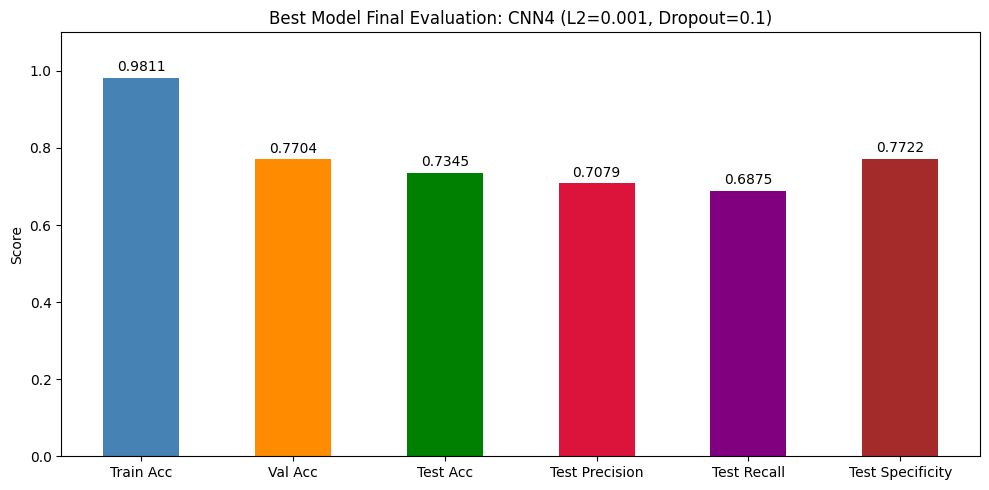

In [ ]:
class CNN4_Final(nn.Module):
    def __init__(self):
        super(CNN4_Final, self).__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 8 * 8, 256),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(256, 64),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(64, 1),
            nn.Sigmoid()
        )
    def forward(self, x):
        return self.classifier(self.features(x))

X_test_cnn = torch.tensor(X_test, dtype=torch.float32).permute(0, 3, 1, 2)

best_model = CNN4_Final().to(device)
optimizer_best = torch.optim.Adam(best_model.parameters(), lr=0.001, weight_decay=0.001)

for epoch in range(epochs):
    best_model.train()
    for X_batch, y_batch in cnn_train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        optimizer_best.zero_grad()
        preds = best_model(X_batch).squeeze()
        loss = criterion(preds, y_batch)
        loss.backward()
        optimizer_best.step()
    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1}/{epochs} complete")

best_model.eval()
with torch.no_grad():
    train_preds = (best_model(X_train_cnn.to(device)).squeeze().cpu().numpy() >= 0.5).astype(int)
    val_preds   = (best_model(X_val_cnn.to(device)).squeeze().cpu().numpy() >= 0.5).astype(int)
    test_preds  = (best_model(X_test_cnn.to(device)).squeeze().cpu().numpy() >= 0.5).astype(int)

train_acc  = accuracy_score(y_train, train_preds)
val_acc    = accuracy_score(y_val, val_preds)
test_acc   = accuracy_score(y_test, test_preds)
test_prec  = precision_score(y_test, test_preds, zero_division=0)
test_rec   = recall_score(y_test, test_preds, zero_division=0)
tn, fp, fn, tp = confusion_matrix(y_test, test_preds).ravel()
test_spec  = tn / (tn + fp)

print(f"\n=== Best Model: CNN4 (L2=0.001, Dropout=0.1) ===")
print(f"Train Accuracy:      {train_acc:.4f}")
print(f"Val Accuracy:        {val_acc:.4f}")
print(f"Test Accuracy:       {test_acc:.4f}")
print(f"Test Precision:      {test_prec:.4f}")
print(f"Test Recall:         {test_rec:.4f}")
print(f"Test Specificity:    {test_spec:.4f}")

metrics = [train_acc, val_acc, test_acc, test_prec, test_rec, test_spec]
labels  = ['Train Acc', 'Val Acc', 'Test Acc', 'Test Precision', 'Test Recall', 'Test Specificity']
colors  = ['steelblue', 'darkorange', 'green', 'crimson', 'purple', 'brown']

plt.figure(figsize=(10, 5))
bars = plt.bar(labels, metrics, color=colors, width=0.5)
for bar, val in zip(bars, metrics):
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01, f'{val:.4f}', ha='center', va='bottom', fontsize=10)
plt.ylim(0, 1.1)
plt.ylabel('Score')
plt.title('Best Model Final Evaluation: CNN4 (L2=0.001, Dropout=0.1)')
plt.tight_layout()
plt.show()